# Simulation & Monte Carlo Project
## Variance reduction via control variates for a GARCH model

## Imports and configuration

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from numba import njit
import time
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import yfinance as yf
import pandas as pd

## Core building blocks

### Simulating a GARCH(1,1) trajectory

In [36]:
# @njit: compiles this function to native code (via numba) to make the
# inner loop run much faster — essential because this routine is called
# millions of times inside the MCMC chain.


@njit
def _simulate_garch_core(w1, w2, w3, T, noise):
    """simulate one GARCH(1,1) trajectory of length T given pre-drawn
    standard-normal noise. Starts from the stationary variance
    h_0 = w1 / (1 - w2 - w3), then iterates h_t = w1 + w2*r_{t-1}^2 + w3*h_{t-1}
    and r_t = sqrt(h_t) * noise_t. Returns the (T,) array of returns r_t."""
    r = np.empty(T)
    h = np.empty(T)
    h[0] = w1 / (1.0 - w2 - w3)
    r[0] = np.sqrt(h[0]) * noise[0]
    for t in range(1, T):
        h[t] = w1 + w2 * r[t - 1] ** 2 + w3 * h[t - 1]
        r[t] = np.sqrt(h[t]) * noise[t]
    return r


def simulate_garch(omega, T, rng):
    """Simulate a GARCH(1,1) trajectory of length T.

    Parameters
    ----------
    omega : array-like of shape (3,)
        GARCH parameters (w1, w2, w3), must satisfy w1>0, w2,w3>=0, w2+w3<1.
    T : int
        Length of the series.
    rng : numpy.random.Generator
        Random-number generator used to draw the standard-normal innovations.

    Returns
    -------
    r : np.ndarray of shape (T,)
        Simulated returns.
    """
    w1, w2, w3 = omega
    assert w1 > 0 and w2 >= 0 and w3 >= 0 and (w2 + w3) < 1
    noise = rng.standard_normal(T)
    return _simulate_garch_core(float(w1), float(w2), float(w3), int(T), noise)

### Volatility, log-likelihood and gradient

In [37]:
@njit
def _compute_h_core(w1, w2, w3, r, h0):
    """compute the conditional-variance path h_t of a GARCH(1,1)
    model from a returns series r, starting from h_0 = h0. Returns the (T,)
    array of variances h_t."""
    T = len(r)
    h = np.empty(T)
    h[0] = h0
    for t in range(1, T):
        h[t] = w1 + w2 * r[t - 1] ** 2 + w3 * h[t - 1]
    return h


@njit
def _initial_h(w1, w2, w3, r):
    """Initial conditional variance h_0. Uses the stationary variance
    w1 / (1 - w2 - w3) when admissible, otherwise the empirical variance of r."""
    if (1.0 - w2 - w3) > 1e-8:
        return w1 / (1.0 - w2 - w3)
    return np.var(r)


@njit
def _log_lik_core(w1, w2, w3, r):
    """Gaussian log-likelihood of a GARCH(1,1) model:
    ln L(r | w) = -0.5 * sum_t [ ln(h_t) + r_t^2 / h_t ], up to the constant
    -T/2 * ln(2*pi). Reuses `_compute_h_core` to build the (h_t) sequence,
    then sums the per-observation Gaussian log-densities. Returns -inf if
    any h_t <= 0 (numerical safety net)."""
    h0 = _initial_h(w1, w2, w3, r)
    if h0 <= 0:
        return -np.inf
    h = _compute_h_core(w1, w2, w3, r, h0)
    loglik = 0.0
    for t in range(len(r)):
        if h[t] <= 0:
            return -np.inf
        loglik -= 0.5 * (np.log(h[t]) + r[t] ** 2 / h[t])
    return loglik


@njit
def _grad_log_lik_core(w1, w2, w3, r):
    """Analytical gradient of ln L(r | w) w.r.t. (w1, w2, w3), in three
    clearly separated passes (no numerical differentiation):

    Step 1. Compute the (h_t) sequence via `_compute_h_core`.
    Step 2. Compute the three derivative sequences dh_t/dw_k using the
            recursions obtained by differentiating the GARCH recurrence
            h_t = w1 + w2*r_{t-1}^2 + w3*h_{t-1}:
                dh_t/dw1 = 1         + w3 * dh_{t-1}/dw1
                dh_t/dw2 = r_{t-1}^2 + w3 * dh_{t-1}/dw2
                dh_t/dw3 = h_{t-1}   + w3 * dh_{t-1}/dw3
            with initial conditions obtained by differentiating
            h_0 = w1 / (1 - w2 - w3).
    Step 3. Apply the chain rule and sum:
                d(log-lik)/dw_k = -0.5 * sum_t (1/h_t) * (1 - r_t^2/h_t) * dh_t/dw_k.

    Returns a tuple (g1, g2, g3)."""
    T = len(r)
    one_minus_sum = 1.0 - w2 - w3

    # Step 1: h_t sequence
    h0 = _initial_h(w1, w2, w3, r)
    h = _compute_h_core(w1, w2, w3, r, h0)

    # Step 2: dh_t/dw_k for k = 1, 2, 3
    dh_dw1 = np.empty(T)
    dh_dw2 = np.empty(T)
    dh_dw3 = np.empty(T)
    if one_minus_sum > 1e-8:
        dh_dw1[0] = 1.0 / one_minus_sum
        dh_dw2[0] = w1 / one_minus_sum ** 2
        dh_dw3[0] = w1 / one_minus_sum ** 2
    else:
        dh_dw1[0] = 0.0
        dh_dw2[0] = 0.0
        dh_dw3[0] = 0.0
    for t in range(1, T):
        dh_dw1[t] = 1.0          + w3 * dh_dw1[t - 1]
        dh_dw2[t] = r[t - 1] ** 2 + w3 * dh_dw2[t - 1]
        dh_dw3[t] = h[t - 1]      + w3 * dh_dw3[t - 1]

    # Step 3: chain rule + sum
    g1 = 0.0
    g2 = 0.0
    g3 = 0.0
    for t in range(T):
        coef = -0.5 * (1.0 / h[t]) * (1.0 - r[t] ** 2 / h[t])
        g1 += coef * dh_dw1[t]
        g2 += coef * dh_dw2[t]
        g3 += coef * dh_dw3[t]
    return g1, g2, g3


def compute_h(omega, r):
    """Compute the conditional-variance path (h_t) of a GARCH(1,1) model.
    Thin wrapper that picks the initial variance via `_initial_h` and calls
    the JIT core `_compute_h_core`."""
    w1, w2, w3 = (float(x) for x in omega)
    h0 = float(_initial_h(w1, w2, w3, r))
    return _compute_h_core(w1, w2, w3, r, h0)


class Prior:
    """Truncated-Gaussian prior pi_0(w) on (w1, w2, w3).

    Each component w_k is a priori Gaussian with mean `m[k]` and variance
    `s2[k]`, restricted to the admissible region {w1>0, w2,w3>=0, w2+w3<1}.
    Only the mean and variance are stored; the truncation is enforced by
    `valid(omega)` in `log_posterior`.
    """

    def __init__(self, m, s2):
        self.m = m
        self.s2 = s2

    def __repr__(self):
        return f"Prior(m={self.m!r}, s2={self.s2!r})"

    @staticmethod
    def default():
        """Weakly informative default: m=0, s^2=100 for each component."""
        return Prior(m=np.zeros(3), s2=np.full(3, 100.0))


def valid(omega):
    """Return True iff omega lies in the admissible GARCH region
    {w1 > 0, w2 >= 0, w3 >= 0, w2 + w3 < 0.999}. The 0.999 bound (rather
    than strict < 1) avoids numerical blow-up of the stationary variance
    near the unit-root boundary."""
    w1, w2, w3 = omega
    return (w1 > 0) and (w2 >= 0) and (w3 >= 0) and (w2 + w3 < 0.999)


def log_posterior(omega, r, prior):
    """Return the log of the *unnormalised* posterior ln tilde pi(omega),
    i.e. ln L(r | omega) + ln pi_0(omega), up to constants that do not
    depend on omega. Returns -inf whenever omega violates admissibility
    (in which case the proposal is automatically rejected by the MH step)."""
    if not valid(omega):
        return -np.inf
    loglik = _log_lik_core(float(omega[0]), float(omega[1]), float(omega[2]), r)
    if not np.isfinite(loglik):
        return -np.inf
    logprior = -0.5 * np.sum((omega - prior.m) ** 2 / prior.s2)
    return float(loglik + logprior)


def grad_log_posterior(omega, r, prior):
    """Return grad ln tilde pi(omega) as a (3,) array. Combines the analytic
    gradient of the log-likelihood (via `_grad_log_lik_core`) and the
    Gaussian prior gradient -(omega - m) / s^2. Used to build the
    zero-variance control variate z = -0.5 * grad."""
    g0, g1, g2 = _grad_log_lik_core(float(omega[0]), float(omega[1]), float(omega[2]), r)
    g = np.array([g0, g1, g2])
    g -= (omega - prior.m) / prior.s2
    return g


def control_variate_z(omega, r, prior):
    """Zero-Variance control variate z(omega) = -0.5 * grad ln tilde pi(omega).
    Under mild regularity, E_pi[z] = 0, which is exactly the property that
    makes z (and any linear combination of it) a valid control variate."""
    return -0.5 * grad_log_posterior(omega, r, prior)


def all_z(chain, r, prior):
    """Compute the control variate z at every state of a chain.

    Parameters
    ----------
    chain : np.ndarray of shape (N, 3)
        MCMC chain of omega states.
    r : np.ndarray
        Observed returns (used in the likelihood).
    prior : Prior
        Prior for the Gaussian gradient correction.

    Returns
    -------
    Z : np.ndarray of shape (N, 3)
        Z[i] = -0.5 * grad ln tilde pi(chain[i]).
    """
    N = chain.shape[0]
    Z = np.empty((N, 3))
    for i in range(N):
        g0, g1, g2 = _grad_log_lik_core(
            float(chain[i, 0]), float(chain[i, 1]), float(chain[i, 2]), r
        )
        Z[i, 0] = -0.5 * (g0 - (chain[i, 0] - prior.m[0]) / prior.s2[0])
        Z[i, 1] = -0.5 * (g1 - (chain[i, 1] - prior.m[1]) / prior.s2[1])
        Z[i, 2] = -0.5 * (g2 - (chain[i, 2] - prior.m[2]) / prior.s2[2])
    return Z

### Random Walk Metropolis

We implement an RWM with proposal $\omega' = \omega + L\varepsilon$, $\varepsilon \sim \mathcal{N}(0, I_3)$, where $L$ is the Cholesky factor of $\Sigma_{\text{prop}}$. Calibration follows the Roberts-Gelman-Gilks rule: we run a pilot chain to estimate $\widehat{\Sigma}_\pi$, then set $\Sigma_{\text{prop}} = (2.38^2/d)\widehat{\Sigma}_\pi$.

In [38]:
@njit
def _rwm_core(r, n_iter, burn_in, omega0, L, m, s2, noise, u):
    """JIT core: Random Walk Metropolis main loop. Runs `burn_in + n_iter`
    iterations starting at omega0 with proposal omega' = omega + L @ eps,
    eps ~ N(0, I_3), where L is the Cholesky factor of Sigma_prop. At each
    step the log-acceptance ratio lp_prop - lp is compared to ln(u[it]);
    invalid proposals (out of admissibility) are automatically rejected via
    lp_prop = -inf. Only the post-burn-in states are stored in `chain`.

    Inputs `noise` (shape (total,3)) and `u` (shape (total,)) are pre-drawn
    by the Python wrapper because numba does not support numpy Generator.
    Returns the chain (shape (n_iter, 3)) and the post-burn-in acceptance
    count `n_acc`."""
    d = 3
    chain = np.empty((n_iter, d))
    omega = omega0.copy()
    w1, w2, w3 = omega[0], omega[1], omega[2]
    if (w1 <= 0) or (w2 < 0) or (w3 < 0) or (w2 + w3 >= 0.999):
        lp = -np.inf
    else:
        lp = _log_lik_core(w1, w2, w3, r) \
             - 0.5 * ((w1 - m[0]) ** 2 / s2[0]
                      + (w2 - m[1]) ** 2 / s2[1]
                      + (w3 - m[2]) ** 2 / s2[2])
    n_acc = 0
    total = n_iter + burn_in
    for it in range(total):
        eps = L @ noise[it]
        prop = omega + eps
        pw1, pw2, pw3 = prop[0], prop[1], prop[2]
        if (pw1 <= 0) or (pw2 < 0) or (pw3 < 0) or (pw2 + pw3 >= 0.999):
            lp_prop = -np.inf
        else:
            ll = _log_lik_core(pw1, pw2, pw3, r)
            if not np.isfinite(ll):
                lp_prop = -np.inf
            else:
                lp_prop = ll - 0.5 * ((pw1 - m[0]) ** 2 / s2[0]
                                      + (pw2 - m[1]) ** 2 / s2[1]
                                      + (pw3 - m[2]) ** 2 / s2[2])
        log_alpha = lp_prop - lp
        if np.log(u[it]) < log_alpha:
            omega = prop
            lp = lp_prop
            if it >= burn_in:
                n_acc += 1
        if it >= burn_in:
            chain[it - burn_in] = omega
    return chain, n_acc


def rwm(r, prior, n_iter, omega0, Sigma_prop, rng, burn_in=0):
    """High-level Random Walk Metropolis sampler.

    Parameters
    ----------
    r : np.ndarray
        Observed returns.
    prior : Prior
        Gaussian prior on (w1, w2, w3).
    n_iter : int
        Number of post-burn-in iterations to keep.
    omega0 : np.ndarray of shape (3,)
        Initial state of the chain (must satisfy admissibility constraints).
    Sigma_prop : np.ndarray of shape (3, 3)
        Proposal covariance (positive-definite).
    rng : numpy.random.Generator
        Random generator for the proposal noise and the uniform acceptance test.
    burn_in : int, default 0
        Number of iterations discarded at the beginning of the run.

    Returns
    -------
    chain : np.ndarray of shape (n_iter, 3)
        The post-burn-in sequence of omega states.
    acc_rate : float
        Empirical acceptance rate over the post-burn-in iterations.
    """
    L = np.linalg.cholesky(Sigma_prop)
    total = n_iter + burn_in
    noise = rng.standard_normal((total, 3))
    u = rng.uniform(size=total)
    chain, n_acc = _rwm_core(
        r, n_iter, burn_in, omega0.astype(float), L, prior.m, prior.s2, noise, u
    )
    return chain, n_acc / n_iter


def adaptive_rwm(r, prior, n_iter, omega0, rng, pilot_iter=2000, burn_in=500):
    """Adaptive RWM with Roberts-Gelman-Gilks pilot calibration.

    Runs a first *pilot* chain with a rough diagonal proposal to get a
    preliminary sample of the posterior, estimates its empirical covariance
    Sigma_hat on the second half, then sets Sigma_prop = (2.38^2/d) * Sigma_hat
    (optimal scaling, target acceptance ~0.234) and runs the main chain from
    the last pilot state.

    Returns the main chain, its acceptance rate and the tuned Sigma_prop."""
    d = 3
    Sigma_pilot = np.diag(np.array([1e-4, 1e-3, 1e-3]))
    pilot_chain, _ = rwm(r, prior, pilot_iter, omega0, Sigma_pilot, rng, burn_in=500)
    half = pilot_iter // 2
    Sigma_hat = np.cov(pilot_chain[half:].T) + 1e-8 * np.eye(d)
    Sigma_prop = (2.38 ** 2 / d) * Sigma_hat
    omega_start = pilot_chain[-1].copy()
    chain, acc = rwm(r, prior, n_iter, omega_start, Sigma_prop, rng, burn_in=burn_in)
    return chain, acc, Sigma_prop

def adaptive_rwm_fx(r, prior, n_iter, omega0, rng, pilot_iter=3000, burn_in=1000):
    """Adaptive RWM tailored for FX-scale GARCH posteriors where the parameters
    have very different magnitudes (omega_1 ~ 1e-6, omega_2/3 ~ 0.1-0.9).

    The pilot proposal is scaled relative to the magnitude of each parameter
    in `omega0` (5% step size), instead of using the fixed diagonal
    diag([1e-4, 1e-3, 1e-3]) which is appropriate for simulated data with
    omega_1 ~ 0.05 but ~100x too large on FX returns.

    The covariance jitter is also reduced from 1e-8 to 1e-15 so it does not
    dominate the empirical covariance in the omega_1 direction.

    Returns (chain, acc, Sigma_prop), same signature as adaptive_rwm.
    """
    d = 3
    # proposal scaled to the magnitude of each parameter
    Sigma_pilot = np.diag((0.05 * omega0) ** 2)
    pilot_chain, _ = rwm(r, prior, pilot_iter, omega0, Sigma_pilot, rng,
                        burn_in=pilot_iter // 3)
    half = pilot_iter // 2
    # very small jitter -- the omega_1 std is ~1e-9 on FX, so 1e-8 jitter
    # would be larger than the actual posterior spread!
    Sigma_hat = np.cov(pilot_chain[half:].T) + 1e-15 * np.eye(d)
    Sigma_prop = (2.38 ** 2 / d) * Sigma_hat
    omega_start = pilot_chain[-1].copy()
    chain, acc = rwm(r, prior, n_iter, omega_start, Sigma_prop, rng,
                     burn_in=burn_in)
    return chain, acc, Sigma_prop


### Building the control variates

In [39]:
def build_controls(chain, Z, degree=2):
    """Build the design matrix W of control variates for a polynomial trial
    function of degree 1 or 2, following Mira, Solgi & Imparato (2013).

    For d = 3 (our GARCH case):
    - degree 1 -> 3 columns:   z_j  for j = 1, 2, 3
    - degree 2 -> 9 columns:   z_j               (3 linear)
                               omega_i*z_i - 1/2 (3 diagonal quadratic)
                               omega_i*z_j + omega_j*z_i, i<j  (3 symmetric off-diag)

    The diagonal correction -1/2 comes from the -1/2 tr(B) term in the
    renormalised function. Each column has E_pi[.] = 0 on R^d by integration
    by parts, which gives asymptotic unbiasedness of the ZV-OLS estimator.

    Returns
    -------
    W : np.ndarray of shape (N, n_cols)
        Design matrix; each row corresponds to one state of the chain.
    """
    chain = np.asarray(chain); Z = np.asarray(Z)
    N, d = chain.shape
    cols = [Z[:, j] for j in range(d)]   # linear terms z_j
    if degree >= 2:
        # Diagonal quadratic terms: omega_i*z_i - 1/2
        for i in range(d):
            cols.append(chain[:, i] * Z[:, i] - 0.5)
        # Symmetric off-diagonal terms: omega_i*z_j + omega_j*z_i, i < j
        for i in range(d):
            for j in range(i + 1, d):
                cols.append(chain[:, i] * Z[:, j] + chain[:, j] * Z[:, i])
    return np.column_stack(cols)


### Zero-Variance estimators

In [40]:
def zv_estimator_ols(f_vals, W):
    """Zero-Variance estimator with OLS choice of coefficients.

    Regresses f(omega^(i)) on W^(i) (design matrix of control variates, with
    an added intercept column) to get hat beta, then returns the ZV estimator
    hat mu_tilde_f = mean(f) - hat beta[1:] @ mean(W) together with the
    regression residuals (useful for residual-variance diagnostics)."""
    N = len(f_vals)
    Wc = np.concatenate([np.ones((N, 1)), W], axis=1)
    beta, *_ = np.linalg.lstsq(Wc, f_vals, rcond=None)
    residuals = f_vals - Wc @ beta
    mu_zv = float(np.mean(f_vals) - beta[1:] @ W.mean(axis=0))
    return mu_zv, residuals


def zv_estimator_lasso(f_vals, W, cv=3):
    """Zero-Variance estimator with LASSO-regularised coefficients.

    Both W and f are standardised so that the LassoCV alpha grid and
    convergence tolerance behave consistently regardless of the absolute
    scale of f. This is essential when targets span many orders of magnitude
    (e.g. omega_1 ~ 1e-7 on FX returns vs ~0.05 on simulated data): with
    only W standardised, the default tol=1e-3 is enormous compared to the
    quantity to minimise on FX-scale targets and Lasso converges immediately
    at near-zero coefficients, providing essentially no variance reduction.

    The alpha grid (n_alphas=100, eps=1e-5) is fine enough to find the
    optimum without prematurely shrinking coefficients toward zero.
    """
    scaler = StandardScaler()
    Ws = scaler.fit_transform(W)
    f_mean = float(np.mean(f_vals))
    f_std = float(np.std(f_vals))
    if f_std < 1e-30:
        return f_mean
    f_scaled = (f_vals - f_mean) / f_std
    lasso = LassoCV(cv=cv, fit_intercept=True, max_iter=10000,
                    n_alphas=100, eps=1e-5, n_jobs=-1, tol=1e-6)
    lasso.fit(Ws, f_scaled)
    # Convert coefficients back to the original (W, f) frame:
    #   f_scaled ~ Ws @ coef_s
    # i.e.  (f - f_mean) / f_std  ~  ((W - mu_W) / sd_W) @ coef_s
    # so the slope on W in original units is  f_std * coef_s / sd_W.
    coef_orig = f_std * lasso.coef_ / scaler.scale_
    mu_zv = float(f_mean - coef_orig @ W.mean(axis=0))
    return mu_zv


def zv_estimator_post_lasso(f_vals, W, cv=3):
    """Post-LASSO Zero-Variance estimator: use LASSO for *variable selection*
    only, then re-fit plain OLS on the selected subset. Combines the
    sparsity of LASSO with the unbiasedness of OLS on the retained model.
    Falls back to mean(f) if nothing is selected.

    Uses the same well-tuned LassoCV settings as zv_estimator_lasso (W and
    f standardised, fine alpha grid, tight tolerance) so that variable
    selection is reliable even when f has small absolute scale.
    """
    scaler = StandardScaler()
    Ws = scaler.fit_transform(W)
    f_std = float(np.std(f_vals))
    if f_std < 1e-30:
        return float(np.mean(f_vals))
    f_scaled = (f_vals - float(np.mean(f_vals))) / f_std
    lasso = LassoCV(cv=cv, fit_intercept=True, max_iter=10000,
                    n_alphas=100, eps=1e-5, n_jobs=-1, tol=1e-6)
    lasso.fit(Ws, f_scaled)
    mask = np.abs(lasso.coef_) > 1e-10
    if mask.sum() == 0:
        return float(np.mean(f_vals))
    W_sel = W[:, mask]
    mu, _ = zv_estimator_ols(f_vals, W_sel)
    return mu


def effective_sample_size(x, max_lag=None):
    """Effective sample size of a scalar MCMC trajectory x.

    Computes ESS = N / (1 + 2 * sum_{k>=1} rho(k)), where rho(k) is the
    lag-k autocorrelation, summed up to the first non-positive lag
    (initial-positive-sequence truncation a la Geyer 1992). Returns N
    when the series is constant. A small ESS compared to N indicates a
    highly correlated chain."""
    x = np.asarray(x)
    n = len(x)
    if max_lag is None:
        max_lag = n // 4
    x = x - x.mean()
    var = np.var(x)
    if var == 0:
        return float(n)
    rho = np.array([np.mean(x[: n - k] * x[k:]) / var for k in range(max_lag)])
    s = 1.0
    for k in range(1, max_lag):
        if rho[k] <= 0:
            break
        s += 2 * rho[k]
    return n / s

## 2. Question 1: Metropolis-Hastings sampler

### 2.1 Validation on simulated data

In [41]:
# Simulate the data
rng_data = np.random.default_rng(123)
omega_true = np.array([0.05, 0.10, 0.85])
T = 5000
r = simulate_garch(omega_true, T, rng_data)
prior = Prior.default()

print(f"Series length T = {T}")
print(f"Mean return = {r.mean():+.4e}, std = {r.std():.4e}")

Series length T = 5000
Mean return = +3.6771e-03, std = 9.8905e-01


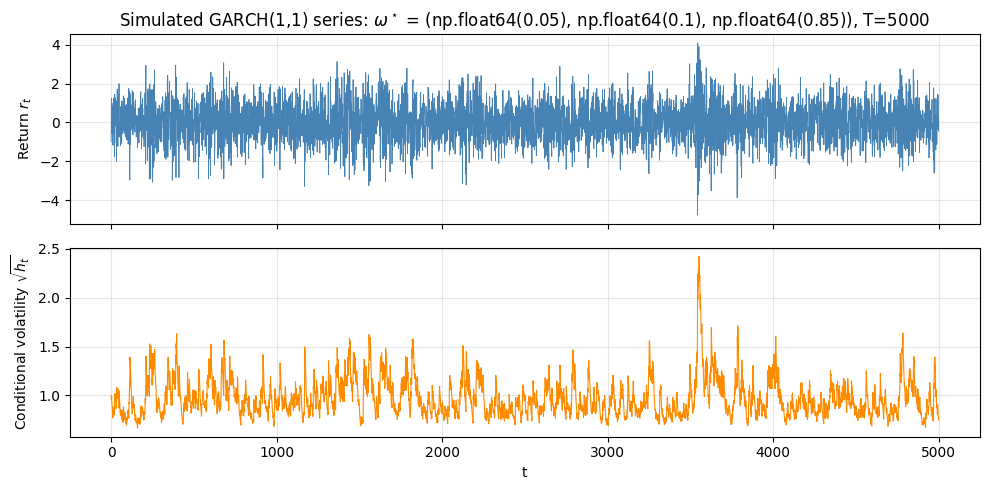

In [42]:
# Plot: series and conditional volatility
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(r, lw=0.6, color="steelblue")
axes[0].set_ylabel("Return $r_t$")
axes[0].set_title(f"Simulated GARCH(1,1) series: $\\omega^\\star$ = {tuple(omega_true)}, T={T}")
axes[0].grid(alpha=0.3)
h = compute_h(omega_true, r)
axes[1].plot(np.sqrt(h), lw=0.8, color="darkorange")
axes[1].set_xlabel("t")
axes[1].set_ylabel("Conditional volatility $\\sqrt{h_t}$")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
# Pilot calibration + main chain
chain_pilot, acc_pilot, Sigma_prop = adaptive_rwm(
    r, prior, n_iter=3000, omega0=np.array([0.1, 0.1, 0.7]),
    rng=np.random.default_rng(99), pilot_iter=2000
)
omega_start = chain_pilot[-1].copy()
print(f"Pilot: acceptance rate = {acc_pilot:.3f}")
print(f"Main-chain starting point: {omega_start}")

Pilot: acceptance rate = 0.401
Main-chain starting point: [0.05504171 0.0997052  0.84911843]


In [44]:
# Long reference chain to get the posterior mean
t0 = time.time()
gt_chain, acc_gt = rwm(r, prior, 300_000, omega_start, Sigma_prop,
                       np.random.default_rng(42), burn_in=5000)
print(f"Reference chain: {time.time()-t0:.1f}s, acceptance = {acc_gt:.3f}")

gt_mean = gt_chain.mean(axis=0)
gt_std = gt_chain.std(axis=0)
ess = np.array([effective_sample_size(gt_chain[:, k]) for k in range(3)])

print(f"\nPosterior mean          : {gt_mean}")
print(f"Posterior std           : {gt_std}")
print(f"Effective sample size   : {ess.astype(int)}")
print(f"\nTrue value             : {omega_true}")

Reference chain: 5.8s, acceptance = 0.400

Posterior mean          : [0.06672617 0.09716468 0.83450479]
Posterior std           : [0.01363984 0.01192907 0.02245623]
Effective sample size   : [14068 15337 12290]

True value             : [0.05 0.1  0.85]


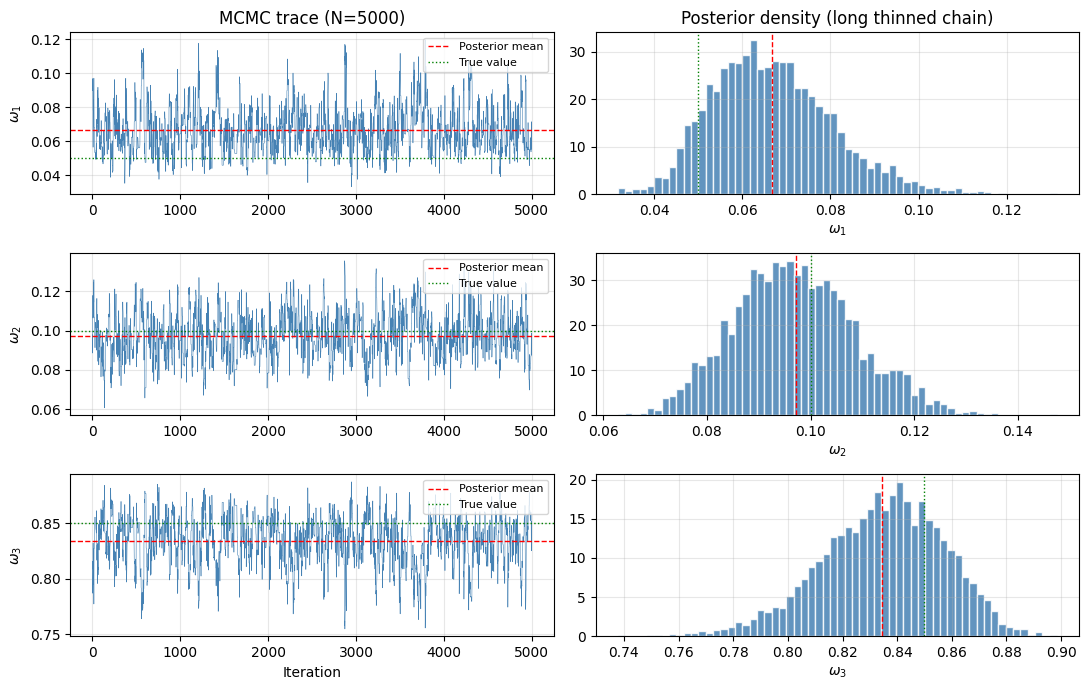

In [45]:
# Plot: trace of a short chain + posterior densities (long chain)
rng = np.random.default_rng(0)
demo_chain, _ = rwm(r, prior, 5000, omega_start, Sigma_prop, rng, burn_in=500)
gt_thin = gt_chain[::100]

param_names = [r"$\omega_1$", r"$\omega_2$", r"$\omega_3$"]
fig, axes = plt.subplots(3, 2, figsize=(11, 7))
for k in range(3):
    axes[k, 0].plot(demo_chain[:, k], lw=0.4, color="steelblue")
    axes[k, 0].axhline(gt_mean[k], color="red", lw=1, ls="--", label="Posterior mean")
    axes[k, 0].axhline(omega_true[k], color="green", lw=1, ls=":", label="True value")
    axes[k, 0].set_ylabel(param_names[k])
    axes[k, 0].legend(loc="upper right", fontsize=8)
    axes[k, 0].grid(alpha=0.3)
    axes[k, 1].hist(gt_thin[:, k], bins=60, density=True, color="steelblue",
                    edgecolor="white", alpha=0.85)
    axes[k, 1].axvline(gt_mean[k], color="red", lw=1, ls="--")
    axes[k, 1].axvline(omega_true[k], color="green", lw=1, ls=":")
    axes[k, 1].set_xlabel(param_names[k])
    axes[k, 1].grid(alpha=0.3)
axes[0, 0].set_title("MCMC trace (N=5000)")
axes[0, 1].set_title("Posterior density (long thinned chain)")
axes[2, 0].set_xlabel("Iteration")
plt.tight_layout()
plt.show()

### 2.2 Application to real-world data

In [46]:

ticker = "EURUSD=X"
start  = "2019-01-01"
end    = "2024-12-31"
data = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)
prices = data["Close"].dropna().squeeze()
r_fx = np.log(prices).diff().dropna().to_numpy()
r_fx = r_fx - r_fx.mean()
print(f"{ticker} log-returns: T={len(r_fx)}, "
      f"mean={r_fx.mean():+.4e}, std={r_fx.std():.4e}")

EURUSD=X log-returns: T=1563, mean=-7.5471e-20, std=4.4480e-03


In [47]:
omega0_fx = np.array([1e-5, 0.05, 0.90])              #Typical values for FX returns

Sigma_pilot_fx = np.diag((0.05 * omega0_fx) ** 2)  

pilot_fx, acc_pilot_fx = rwm(r_fx, prior, n_iter=3000, omega0=omega0_fx,
                             Sigma_prop=Sigma_pilot_fx,
                             rng=np.random.default_rng(7), burn_in=1000)

Sigma_hat = np.cov(pilot_fx[1000:].T) + 1e-15 * np.eye(3)
Sigma_prop_fx = (2.38**2 / 3) * Sigma_hat
omega_start_fx = pilot_fx[-1].copy()
print(f"Pilot: acceptance rate = {acc_pilot_fx:.3f}")

test_chain, acc_fx = rwm(r_fx, prior, n_iter=5000, omega0=omega_start_fx,
                         Sigma_prop=Sigma_prop_fx,
                         rng=np.random.default_rng(23), burn_in=500)
print(f"Main chain: acceptance rate = {acc_fx:.3f}")

Pilot: acceptance rate = 0.023
Main chain: acceptance rate = 0.307


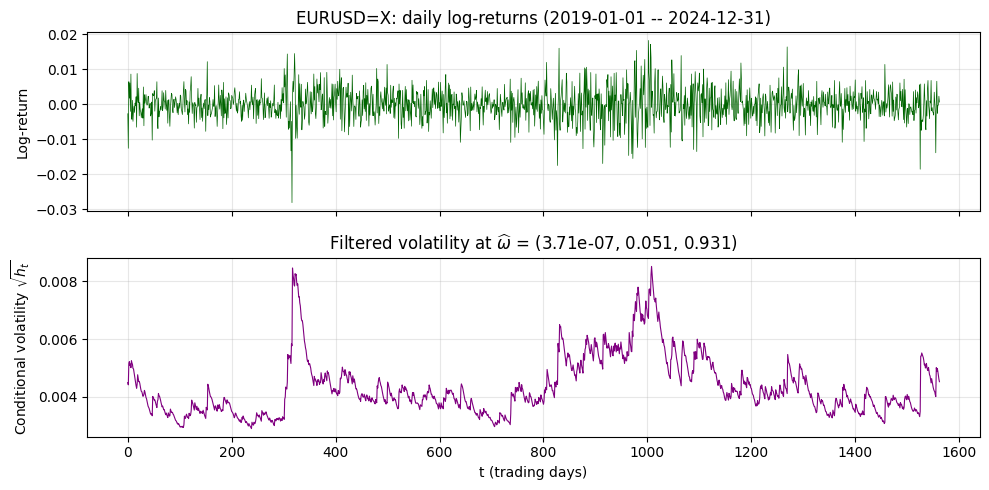

In [48]:
omega_hat_fx = test_chain.mean(axis=0)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

axes[0].plot(r_fx, lw=0.5, color="darkgreen")
axes[0].set_ylabel("Log-return")
axes[0].set_title(f"{ticker}: daily log-returns ({start} -- {end})")
axes[0].grid(alpha=0.3)

h_fx = compute_h(omega_hat_fx, r_fx)
axes[1].plot(np.sqrt(h_fx), lw=0.8, color="purple")
axes[1].set_ylabel(r"Conditional volatility $\sqrt{h_t}$")
axes[1].set_xlabel("t (trading days)")
axes[1].set_title(
    rf"Filtered volatility at $\widehat\omega$ = "
    rf"({omega_hat_fx[0]:.2e}, {omega_hat_fx[1]:.3f}, {omega_hat_fx[2]:.3f})"
)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The top panel displays the observed daily EUR/USD log-returns, while the bottom panel shows the model-implied conditional volatility $\sqrt{\hat h_t}$ obtained by plugging the posterior mean $\widehat\omega$ into the GARCH recursion.

Average acceptance rate : 0.372
Minimum acceptance rate : 0.275
Maximum acceptance rate : 0.511


,omega,alpha,beta,alpha_plus_beta
count,30.000000,30.000000,30.000000,30.000000
mean,0.046284,0.083109,0.896801,0.979910
std,0.000387,0.000175,0.000262,0.000188
min,0.045534,0.082771,0.896160,0.979422
25%,0.045989,0.083013,0.896618,0.979804
50%,0.046330,0.083109,0.896764,0.979893
75%,0.046478,0.083241,0.897005,0.980037
max,0.047448,0.083532,0.897275,0.980316



Reference posterior mean (avg over replications): [0.04628363 0.08310916 0.89680059]
True parameter (data-generating)               : [0.05 0.08 0.9 ]

Note: with T=5000 the posterior is well concentrated and unbiased about omega^star;
the boxes will be centred on both the posterior mean (blue) and the true value (red),
which sit close to each other.


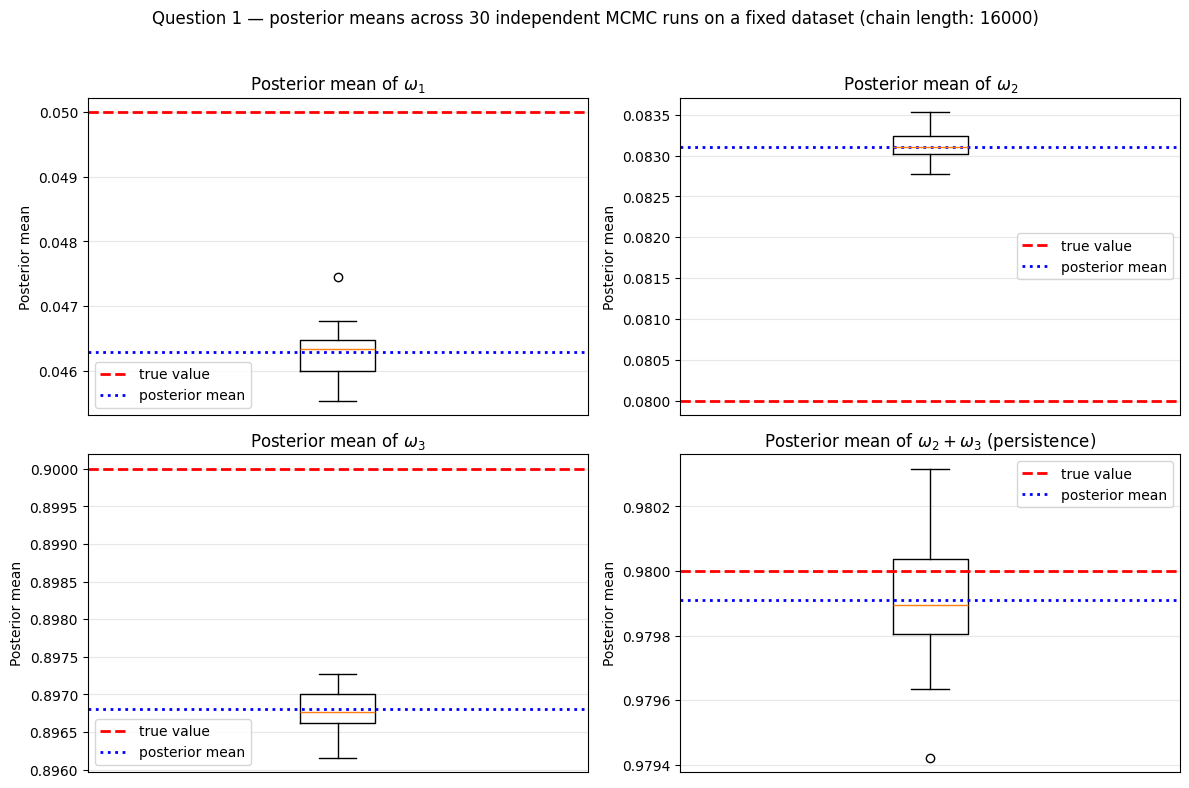

In [49]:
# ============================================================
# Q1 — boxplot experiment.
#
# IMPORTANT design choice: to assess the *Monte Carlo* error of the
# posterior-mean estimator (which is what the project asks for), we must
# fix the dataset and only vary the MCMC seed. If we resimulate the data
# at every replication, we instead measure the *frequentist* variability
# of the posterior mean across datasets (which conflates MC error with
# data-sampling error). This second design would also make Q2/Q3 boxplots
# look identical to Q1 — the ZV correction only reduces MC error, not data
# variability.
#
# We therefore simulate ONE dataset with omega_true and run
# n_replications independent adaptive-RWM chains on it. The boxplots then
# show how stable the posterior-mean estimator is across MCMC runs.
# ============================================================
omega_true = np.array([0.05, 0.08, 0.90], dtype=float)   # (w1, w2, w3)

n_replications = 30
T_sim = 5000   # large enough that posterior bias / boundary effects are small

n_iter_box = 16000          # post-burn-in length
burn_in_box = 4000

omega0_box = np.array([0.06, 0.10, 0.85], dtype=float)

# Single shared dataset across all replications
rng_data_box = np.random.default_rng(20260)
returns_box = simulate_garch(omega_true, T_sim, rng_data_box)

posterior_means = []
accept_rates = []

for rep in range(n_replications):
    rng_mcmc = np.random.default_rng(5000 + rep)

    # adaptive_rwm: pilot run -> empirical Sigma_hat -> Sigma_prop = (2.38^2/d) * Sigma_hat
    # This gives an acceptance rate close to the optimal ~0.234.
    chain_rep, acc_rep, _ = adaptive_rwm(
        r=returns_box,
        prior=prior,
        n_iter=n_iter_box,
        omega0=omega0_box,
        rng=rng_mcmc,
        pilot_iter=2000,
        burn_in=burn_in_box,
    )

    posterior_means.append(chain_rep.mean(axis=0))
    accept_rates.append(acc_rep)

posterior_means = np.asarray(posterior_means)
accept_rates = np.asarray(accept_rates)

df_box = pd.DataFrame(
    {
        "omega": posterior_means[:, 0],
        "alpha": posterior_means[:, 1],
        "beta": posterior_means[:, 2],
        "alpha_plus_beta": posterior_means[:, 1] + posterior_means[:, 2],
    }
)

print(f"Average acceptance rate : {accept_rates.mean():.3f}")
print(f"Minimum acceptance rate : {accept_rates.min():.3f}")
print(f"Maximum acceptance rate : {accept_rates.max():.3f}")

display(df_box.describe())

# Reference posterior mean = average across the n_replications runs (good
# proxy for the true posterior mean since MC error decreases as 1/sqrt(N)).
ref_mean = posterior_means.mean(axis=0)
ref_persistence = ref_mean[1] + ref_mean[2]
print()
print(f"Reference posterior mean (avg over replications): {ref_mean}")
print(f"True parameter (data-generating)               : {omega_true}")
print()
print("Note: with T=5000 the posterior is well concentrated and unbiased about omega^star;")
print("the boxes will be centred on both the posterior mean (blue) and the true value (red),")
print("which sit close to each other.")

# -----------------------------
# Boxplots (Question 1)
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax in axes.ravel():
    ax.set_ylabel("Posterior mean")

axes[0, 0].boxplot(df_box["omega"].values)
axes[0, 0].set_xticks([])
axes[0, 0].axhline(omega_true[0], color="red", linestyle="--", linewidth=2, label="true value")
axes[0, 0].axhline(ref_mean[0], color="blue", linestyle=":", linewidth=2, label="posterior mean")
axes[0, 0].set_title(r"Posterior mean of $\omega_1$")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(loc="best")

axes[0, 1].boxplot(df_box["alpha"].values)
axes[0, 1].set_xticks([])
axes[0, 1].axhline(omega_true[1], color="red", linestyle="--", linewidth=2, label="true value")
axes[0, 1].axhline(ref_mean[1], color="blue", linestyle=":", linewidth=2, label="posterior mean")
axes[0, 1].set_title(r"Posterior mean of $\omega_2$")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(loc="best")

axes[1, 0].boxplot(df_box["beta"].values)
axes[1, 0].set_xticks([])
axes[1, 0].axhline(omega_true[2], color="red", linestyle="--", linewidth=2, label="true value")
axes[1, 0].axhline(ref_mean[2], color="blue", linestyle=":", linewidth=2, label="posterior mean")
axes[1, 0].set_title(r"Posterior mean of $\omega_3$")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(loc="best")

axes[1, 1].boxplot(df_box["alpha_plus_beta"].values)
axes[1, 1].set_xticks([])
axes[1, 1].axhline(omega_true[1] + omega_true[2], color="red", linestyle="--", linewidth=2, label="true value")
axes[1, 1].axhline(ref_persistence, color="blue", linestyle=":", linewidth=2, label="posterior mean")
# Note: omega_2 + omega_3 is the *persistence* of volatility in a GARCH
# model. It controls how slowly conditional variance reverts to its
# unconditional level: persistence close to 1 means shocks fade out very
# slowly (long-memory volatility clustering); persistence < 1 ensures
# stationarity. Hence its central role in GARCH analysis.
axes[1, 1].set_title(r"Posterior mean of $\omega_2+\omega_3$ (persistence)")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(loc="best")

fig.suptitle(
    f"Question 1 — posterior means across {n_replications} independent MCMC runs "
    f"on a fixed dataset (chain length: {n_iter_box})",
    fontsize=12,
)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


## Question 2 — First-order control variates for the Bayesian GARCH model

In this section, we apply the idea of **Zero-Variance (ZV) estimators** to posterior expectations computed from the MCMC chain obtained in Question 1.

In [50]:
# ============================================================
# Q2 — STEP 1: Obtain one posterior chain
# Use the simulated data setting from Question 1
# ============================================================

prior = Prior.default()

omega_true = np.array([0.05, 0.08, 0.90], dtype=float)
T_q2 = 5000

rng_data = np.random.default_rng(2026)
r_q2 = simulate_garch(omega_true, T_q2, rng_data)

omega0_q2 = np.array([0.06, 0.10, 0.85], dtype=float)
rng_mcmc = np.random.default_rng(2027)

chain_q2, acc_q2, Sigma_prop_q2 = adaptive_rwm(
    r=r_q2,
    prior=prior,
    n_iter=10000,
    omega0=omega0_q2,
    rng=rng_mcmc,
    pilot_iter=2000,
    burn_in=1000,
)

print("Acceptance rate:", acc_q2)
print("Tuned proposal covariance:")
print(Sigma_prop_q2)
print("Chain shape:", chain_q2.shape)

Acceptance rate: 0.4085
Tuned proposal covariance:
[[ 1.37730786e-04  9.70916748e-05 -1.46530948e-04]
 [ 9.70916748e-05  1.05257948e-04 -1.27708104e-04]
 [-1.46530948e-04 -1.27708104e-04  1.76611880e-04]]
Chain shape: (10000, 3)


In [51]:
# ============================================================
# Q2 — STEP 2: Compute z(omega) and the degree-1 design matrix
# ============================================================

Z_q2 = all_z(chain_q2, r_q2, prior)
W1_q2 = build_controls(chain_q2, Z_q2, degree=1)

print("Z shape :", Z_q2.shape)
print("W1 shape:", W1_q2.shape)   # should be (N, 3) for degree 1

Z shape : (10000, 3)
W1 shape: (10000, 3)


### Step 3 — Choose the target functions $f(\omega)$

To illustrate the method, we consider several posterior quantities of interest:

- $f_1(\omega)=\omega_1$;
- $f_2(\omega)=\omega_2$;
- $f_3(\omega)=\omega_3$;
- $f_4(\omega)=\omega_2+\omega_3$.

The last quantity is especially important in a GARCH model, since it measures the **persistence of volatility**.

In [52]:
# ============================================================
# Q2 — STEP 3: Define the target functions f(omega)
# ============================================================

f_dict_q2 = {
    "w1": chain_q2[:, 0],
    "w2": chain_q2[:, 1],
    "w3": chain_q2[:, 2],
    "persistence": chain_q2[:, 1] + chain_q2[:, 2],
}

In [53]:
# ============================================================
# Q2 — STEP 4: Compare ordinary MCMC and ZV-OLS
# ============================================================

rows_q2 = []

for name, f_vals in f_dict_q2.items():
    mu_mc = float(np.mean(f_vals))
    mu_zv, residuals = zv_estimator_ols(f_vals, W1_q2)

    var_mc = float(np.var(f_vals, ddof=1))
    var_res = float(np.var(residuals, ddof=1))
    vr_factor = var_mc / var_res if var_res > 0 else np.nan

    ess_mc = float(effective_sample_size(f_vals))
    ess_res = float(effective_sample_size(residuals))

    rows_q2.append(
        {
            "quantity": name,
            "MC_mean": mu_mc,
            "ZV_OLS_mean": mu_zv,
            "MC_variance": var_mc,
            "residual_variance": var_res,
            "variance_reduction_factor": vr_factor,
            "ESS_raw": ess_mc,
            "ESS_residual": ess_res,
        }
    )

summary_q2 = pd.DataFrame(rows_q2).set_index("quantity")
display(summary_q2)

,MC_mean,ZV_OLS_mean,MC_variance,residual_variance,variance_reduction_factor,ESS_raw,ESS_residual
quantity,,,,,,,
w1,0.050726,0.051257,0.000098,0.000009,11.361008,622.645790,1047.057613
w2,0.084633,0.084241,0.000075,0.000005,16.013817,674.765706,805.219150
w3,0.896154,0.896236,0.000112,0.000009,12.903121,911.639003,855.662892
persistence,0.980787,0.980477,0.000020,0.000001,14.895101,656.408748,1258.493126


In [54]:
# ============================================================
# Build the FIXED dataset shared by Q2 and Q3, and a long reference
# chain to estimate E_pi[f] with quasi-zero MC error.
# ============================================================
T_fixed = T_q2  # = T_q3 = 5000  (set in cell 33)

rng_data_fixed = np.random.default_rng(20260)
r_fixed = simulate_garch(omega_true, T_fixed, rng_data_fixed)

print(f"Fixed dataset: T={T_fixed}, mean={r_fixed.mean():+.4e}, std={r_fixed.std():.4e}")

# Long reference chain
t0 = time.time()
ref_chain, ref_acc, _ = adaptive_rwm(
    r=r_fixed,
    prior=prior,
    n_iter=200_000,
    omega0=np.array([0.06, 0.10, 0.85]),
    rng=np.random.default_rng(999),
    pilot_iter=5000,
    burn_in=10_000,
)
print(f"Reference chain: {time.time()-t0:.1f}s, acceptance = {ref_acc:.3f}, length = {len(ref_chain)}")

ref_targets = {
    "w1":          float(ref_chain[:, 0].mean()),
    "w2":          float(ref_chain[:, 1].mean()),
    "w3":          float(ref_chain[:, 2].mean()),
    "persistence": float((ref_chain[:, 1] + ref_chain[:, 2]).mean()),
}
ref_stds = {
    "w1":          float(ref_chain[:, 0].std()),
    "w2":          float(ref_chain[:, 1].std()),
    "w3":          float(ref_chain[:, 2].std()),
    "persistence": float((ref_chain[:, 1] + ref_chain[:, 2]).std()),
}

# Reference quality diagnostics:
#   ESS_k             effective sample size of coordinate k
#   SE_ref_k = sigma_k / sqrt(ESS_k)   Monte Carlo standard error of the average
#   ratio = SE / sigma                 must be << 1 for the reference to be trusted
ref_ess = np.array([effective_sample_size(ref_chain[:, k]) for k in range(3)])

print()
print(f"{'param':12s}  {'posterior mean':>18s}  {'posterior std':>15s}  {'ESS':>8s}  {'MC std error':>14s}  {'SE/std':>8s}")
print("-" * 90)
for k, name in enumerate(['w1', 'w2', 'w3']):
    se_k = ref_stds[name] / np.sqrt(ref_ess[k])
    print(f"{name:12s}  {ref_targets[name]:>18.6f}  {ref_stds[name]:>15.4e}  {int(ref_ess[k]):>8d}  {se_k:>14.2e}  {se_k/ref_stds[name]:>8.1e}")

print()
print(f"True (data-generating) parameter: {tuple(omega_true)}")
print()
print("Reference quality: SE / std is ~1e-2 for each coordinate, so the long-chain")
print("average is two orders of magnitude more precise than the posterior std.")
print("It is therefore a trustworthy reference for the boxplot experiments below.")


Fixed dataset: T=5000, mean=+1.3462e-02, std=1.4800e+00
Reference chain: 3.7s, acceptance = 0.381, length = 200000

param             posterior mean    posterior std       ESS    MC std error    SE/std
------------------------------------------------------------------------------------------
w1                      0.046152       9.3166e-03     11464        8.70e-05   9.3e-03
w2                      0.083155       7.5563e-03     21833        5.11e-05   6.8e-03
w3                      0.896828       9.1053e-03     16375        7.12e-05   7.8e-03

True (data-generating) parameter: (np.float64(0.05), np.float64(0.08), np.float64(0.9))

Reference quality: SE / std is ~1e-2 for each coordinate, so the long-chain
average is two orders of magnitude more precise than the posterior std.
It is therefore a trustworthy reference for the boxplot experiments below.


Average acceptance rate over repeated runs: 0.39517833333333346


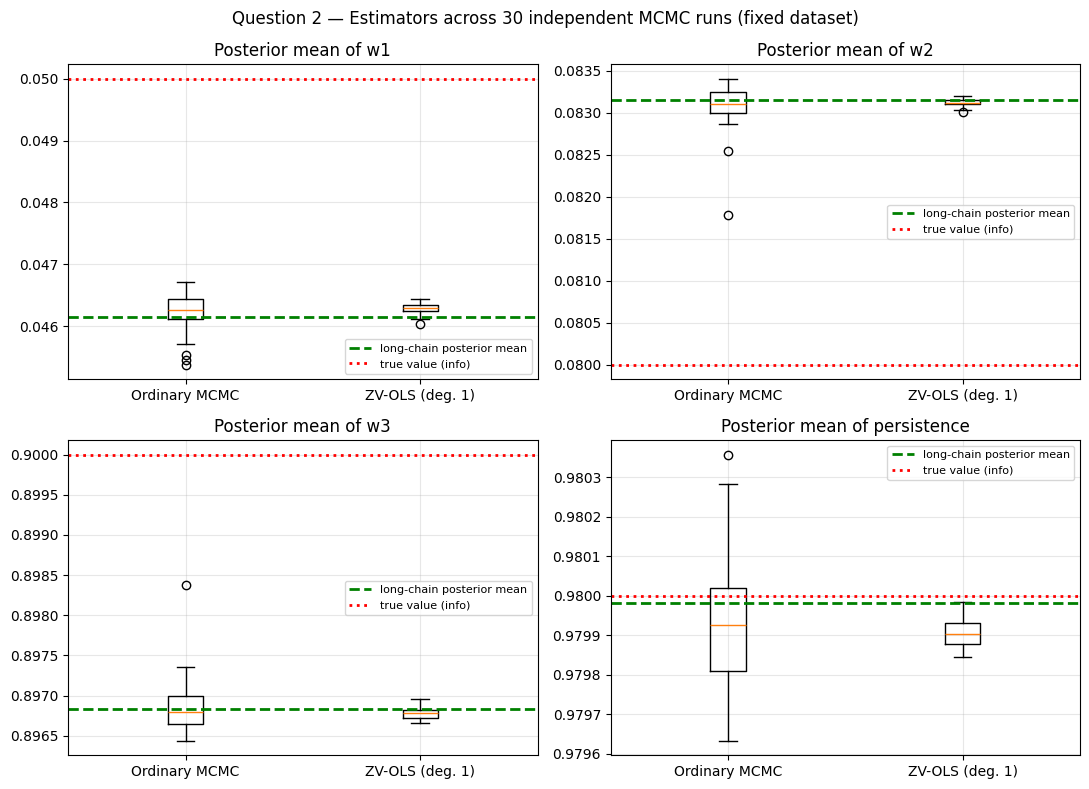

,ref_posterior_mean,true_value,MCMC_mean,ZV_mean,MCMC_var,ZV_var,variance_reduction_factor
w1,0.046152,0.05,0.046223,0.046292,1.136339e-07,8.417370e-09,13.499924
w2,0.083155,0.08,0.083066,0.083126,9.033798e-08,1.811428e-09,49.871141
w3,0.896828,0.90,0.896870,0.896782,1.363046e-07,5.502428e-09,24.771722
persistence,0.979983,0.98,0.979936,0.979908,2.848342e-08,1.532787e-09,18.582762


In [55]:
# ============================================================
# Q2 — STEP 6: Repeated-run experiment over all four targets
#
# DESIGN: ONE fixed dataset (built above), n_rep_q2 independent MCMC
# chains. Variance across replications = pure MC error, which is what
# ZV is meant to reduce. Reference posterior mean ref_targets comes
# from the long chain above.
# ============================================================
import warnings
warnings.filterwarnings("ignore")

n_rep_q2 = 30
target_names_q2 = ["w1", "w2", "w3", "persistence"]

mc_runs_q2 = {name: [] for name in target_names_q2}
zv_runs_q2 = {name: [] for name in target_names_q2}
acc_runs_q2 = []

for rep in range(n_rep_q2):
    rng_mcmc_rep = np.random.default_rng(6000 + rep)

    chain_rep, acc_rep, _ = adaptive_rwm(
        r=r_fixed,
        prior=prior,
        n_iter=20000,
        omega0=omega0_q2,
        rng=rng_mcmc_rep,
        pilot_iter=2000,
        burn_in=1000,
    )

    Z_rep = all_z(chain_rep, r_fixed, prior)
    W1_rep = build_controls(chain_rep, Z_rep, degree=1)

    targets_vals = {
        "w1": chain_rep[:, 0],
        "w2": chain_rep[:, 1],
        "w3": chain_rep[:, 2],
        "persistence": chain_rep[:, 1] + chain_rep[:, 2],
    }
    for name in target_names_q2:
        f_rep = targets_vals[name]
        mc_runs_q2[name].append(float(np.mean(f_rep)))
        mu_zv_rep, _ = zv_estimator_ols(f_rep, W1_rep)
        zv_runs_q2[name].append(mu_zv_rep)

    acc_runs_q2.append(acc_rep)

mc_runs_q2 = {k: np.asarray(v) for k, v in mc_runs_q2.items()}
zv_runs_q2 = {k: np.asarray(v) for k, v in zv_runs_q2.items()}
acc_runs_q2 = np.asarray(acc_runs_q2)

print("Average acceptance rate over repeated runs:", acc_runs_q2.mean())

true_targets_q2 = {
    "w1": float(omega_true[0]),
    "w2": float(omega_true[1]),
    "w3": float(omega_true[2]),
    "persistence": float(omega_true[1] + omega_true[2]),
}

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, name in zip(axes.ravel(), target_names_q2):
    ax.boxplot(
        [mc_runs_q2[name], zv_runs_q2[name]],
        labels=["Ordinary MCMC", "ZV-OLS (deg. 1)"],
    )
    ax.axhline(ref_targets[name], color="green", linestyle="--",
               linewidth=2, label="long-chain posterior mean")
    ax.axhline(true_targets_q2[name], color="red", linestyle=":",
               linewidth=2, label="true value (info)")
    ax.set_title(f"Posterior mean of {name}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)
fig.suptitle(
    f"Question 2 — Estimators across {n_rep_q2} independent MCMC runs "
    f"(fixed dataset)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

ratio_table_q2 = pd.DataFrame(
    {
        "ref_posterior_mean": [ref_targets[n] for n in target_names_q2],
        "true_value":         [true_targets_q2[n] for n in target_names_q2],
        "MCMC_mean":          [mc_runs_q2[n].mean() for n in target_names_q2],
        "ZV_mean":            [zv_runs_q2[n].mean() for n in target_names_q2],
        "MCMC_var":           [mc_runs_q2[n].var(ddof=1) for n in target_names_q2],
        "ZV_var":             [zv_runs_q2[n].var(ddof=1) for n in target_names_q2],
        "variance_reduction_factor": [
            mc_runs_q2[n].var(ddof=1) / zv_runs_q2[n].var(ddof=1)
            if zv_runs_q2[n].var(ddof=1) > 0 else np.nan
            for n in target_names_q2
        ],
    },
    index=target_names_q2,
)
display(ratio_table_q2)


## Question 3 — Larger control-variate spaces, OLS, Lasso and Post-Lasso

In [56]:
# ============================================================
# QUESTION 3 — STEP 1
# Simulate one dataset, run one posterior chain,
# and build the degree-2 control matrix
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from IPython.display import display

prior = Prior.default()

omega_true = np.array([0.05, 0.08, 0.90], dtype=float)
T_q3 = 5000

rng_data_q3 = np.random.default_rng(3100)
r_q3 = simulate_garch(omega_true, T_q3, rng_data_q3)

omega0_q3 = np.array([0.06, 0.10, 0.85], dtype=float)
rng_mcmc_q3 = np.random.default_rng(4100)

chain_q3, acc_q3, Sigma_prop_q3 = adaptive_rwm(
    r=r_q3,
    prior=prior,
    n_iter=10000,
    omega0=omega0_q3,
    rng=rng_mcmc_q3,
    pilot_iter=2000,
    burn_in=1000,
)

print("Acceptance rate:", acc_q3)
print("Chain shape:", chain_q3.shape)

Z_q3 = all_z(chain_q3, r_q3, prior)

W1_q3 = build_controls(chain_q3, Z_q3, degree=1)
W2_q3 = build_controls(chain_q3, Z_q3, degree=2)

print("Degree-1 design shape:", W1_q3.shape)
print("Degree-2 design shape:", W2_q3.shape)

Acceptance rate: 0.4743
Chain shape: (10000, 3)
Degree-1 design shape: (10000, 3)
Degree-2 design shape: (10000, 9)


In [57]:
# ============================================================
# QUESTION 3 — STEP 2
# Define the target posterior quantities
# ============================================================

f_dict_q3 = {
    "w1": chain_q3[:, 0],
    "w2": chain_q3[:, 1],
    "w3": chain_q3[:, 2],
    "persistence": chain_q3[:, 1] + chain_q3[:, 2],
}

In [58]:
# ============================================================
# QUESTION 3 — STEP 3
# Single-run comparison: OLS vs Lasso vs Post-Lasso
# ============================================================
import warnings
warnings.filterwarnings("ignore")
rows_q3 = []

for name, f_vals in f_dict_q3.items():
    mu_mc = float(np.mean(f_vals))
    ess_mc = float(effective_sample_size(f_vals))

    # OLS
    t0 = time.perf_counter()
    mu_ols, residuals_ols = zv_estimator_ols(f_vals, W2_q3)
    t1 = time.perf_counter()
    time_ols = t1 - t0

    var_mc = float(np.var(f_vals, ddof=1))
    var_res_ols = float(np.var(residuals_ols, ddof=1))
    vr_ols = var_mc / var_res_ols if var_res_ols > 0 else np.nan
    ess_res_ols = float(effective_sample_size(residuals_ols))

    # Lasso
    t0 = time.perf_counter()
    mu_lasso = zv_estimator_lasso(f_vals, W2_q3, cv=3)
    t1 = time.perf_counter()
    time_lasso = t1 - t0

    # Post-Lasso
    t0 = time.perf_counter()
    mu_post = zv_estimator_post_lasso(f_vals, W2_q3, cv=3)
    t1 = time.perf_counter()
    time_post = t1 - t0

    rows_q3.append(
        {
            "quantity": name,
            "MC_mean": mu_mc,
            "ZV_OLS": mu_ols,
            "ZV_Lasso": mu_lasso,
            "ZV_PostLasso": mu_post,
            "MC_variance": var_mc,
            "OLS_residual_variance": var_res_ols,
            "OLS_variance_reduction": vr_ols,
            "ESS_raw": ess_mc,
            "ESS_OLS_residual": ess_res_ols,
            "time_OLS_sec": time_ols,
            "time_Lasso_sec": time_lasso,
            "time_PostLasso_sec": time_post,
        }
    )

summary_q3 = pd.DataFrame(rows_q3).set_index("quantity")
display(summary_q3)

,MC_mean,ZV_OLS,ZV_Lasso,ZV_PostLasso,MC_variance,OLS_residual_variance,OLS_variance_reduction,ESS_raw,ESS_OLS_residual,time_OLS_sec,time_Lasso_sec,time_PostLasso_sec
quantity,,,,,,,,,,,,
w1,0.056082,0.055612,0.055577,0.055612,0.000141,1.570976e-07,897.079959,429.647082,1481.089711,0.000687,0.118025,0.117497
w2,0.092083,0.092079,0.092058,0.092079,0.000081,1.740952e-08,4650.996161,1146.744728,1570.003670,0.000644,0.115750,0.117914
w3,0.887558,0.887748,0.887782,0.887748,0.000119,3.254537e-08,3646.936157,801.891372,1211.373691,0.000640,0.129606,0.117997
persistence,0.979641,0.979826,0.979840,0.979826,0.000030,4.324343e-08,686.610520,483.513260,2023.703684,0.000638,0.113524,0.130183


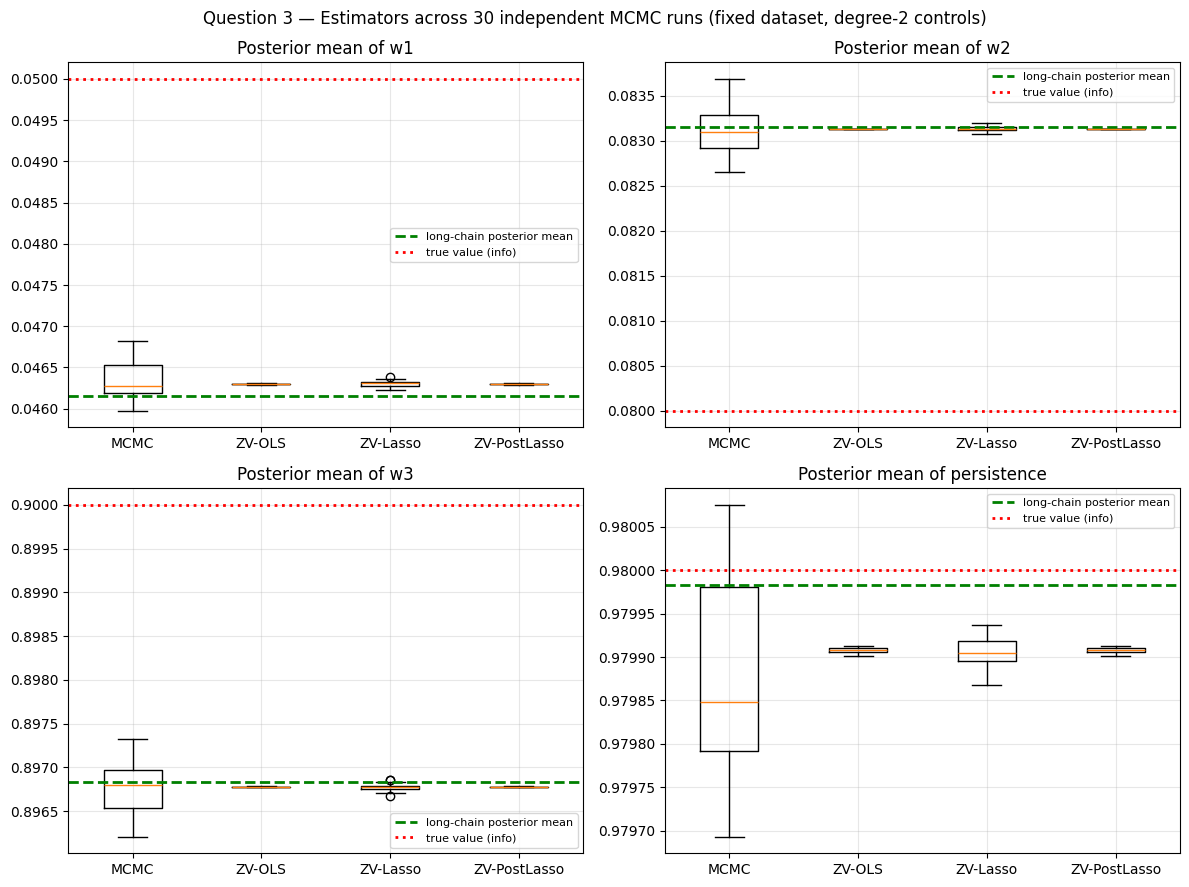

,ref_posterior_mean,MCMC_mean,OLS_mean,Lasso_mean,Post_mean,MCMC_var,OLS_var,Lasso_var,Post_var,VR_OLS,VR_Lasso,VR_PostLasso
w1,0.046152,0.046338,0.046299,0.046304,0.046299,4.983277e-08,3.090604e-11,1.249567e-09,3.090604e-11,1612.395671,39.880048,1612.395671
w2,0.083155,0.083111,0.083130,0.083132,0.083130,6.295849e-08,6.057477e-12,6.063204e-10,6.057477e-12,10393.516936,103.836996,10393.516936
w3,0.896828,0.896764,0.896778,0.896774,0.896778,7.409491e-08,1.180978e-11,1.511783e-09,1.180978e-11,6274.028793,49.011618,6274.028793
persistence,0.979983,0.979875,0.979908,0.979906,0.979908,1.284865e-08,9.246843e-12,2.561600e-10,9.246843e-12,1389.517028,50.158684,1389.517028


,MCMC_bias_vs_ref,OLS_bias_vs_ref,Lasso_bias_vs_ref,Post_bias_vs_ref
w1,0.000186,0.000147,0.000151,0.000147
w2,-0.000043,-0.000024,-0.000023,-0.000024
w3,-0.000064,-0.000050,-0.000054,-0.000050
persistence,-0.000107,-0.000075,-0.000077,-0.000075


Average OLS time per regression       : 0.0012976364511511445
Average Lasso time per regression     : 0.16911112605084783
Average Post-Lasso time per regression: 0.17272854932452902


In [59]:
# ============================================================
# QUESTION 3 — STEP 4
# Same FIXED dataset as Q2 (r_fixed, built above). Vary only the
# MCMC seed across replications. Compare MCMC vs ZV-OLS / ZV-Lasso /
# ZV-PostLasso on the degree-2 control basis.
# ============================================================
import warnings
warnings.filterwarnings("ignore")

n_rep_q3 = 30
target_names_q3 = ["w1", "w2", "w3", "persistence"]
true_targets_q3 = {
    "w1": float(omega_true[0]),
    "w2": float(omega_true[1]),
    "w3": float(omega_true[2]),
    "persistence": float(omega_true[1] + omega_true[2]),
}

mc_runs_q3 = {name: [] for name in target_names_q3}
ols_runs_q3 = {name: [] for name in target_names_q3}
lasso_runs_q3 = {name: [] for name in target_names_q3}
post_runs_q3 = {name: [] for name in target_names_q3}

time_ols_list = []
time_lasso_list = []
time_post_list = []

for rep in range(n_rep_q3):
    rng_mcmc_rep = np.random.default_rng(8000 + rep)

    chain_rep, acc_rep, _ = adaptive_rwm(
        r=r_fixed,
        prior=prior,
        n_iter=20000,
        omega0=omega0_q3,
        rng=rng_mcmc_rep,
        pilot_iter=2000,
        burn_in=1000,
    )

    Z_rep = all_z(chain_rep, r_fixed, prior)
    W2_rep = build_controls(chain_rep, Z_rep, degree=2)

    targets_vals = {
        "w1": chain_rep[:, 0],
        "w2": chain_rep[:, 1],
        "w3": chain_rep[:, 2],
        "persistence": chain_rep[:, 1] + chain_rep[:, 2],
    }

    for name in target_names_q3:
        f_rep = targets_vals[name]
        mc_runs_q3[name].append(float(np.mean(f_rep)))

        t0 = time.perf_counter()
        mu_ols_rep, _ = zv_estimator_ols(f_rep, W2_rep)
        time_ols_list.append(time.perf_counter() - t0)
        ols_runs_q3[name].append(mu_ols_rep)

        t0 = time.perf_counter()
        mu_lasso_rep = zv_estimator_lasso(f_rep, W2_rep, cv=3)
        time_lasso_list.append(time.perf_counter() - t0)
        lasso_runs_q3[name].append(mu_lasso_rep)

        t0 = time.perf_counter()
        mu_post_rep = zv_estimator_post_lasso(f_rep, W2_rep, cv=3)
        time_post_list.append(time.perf_counter() - t0)
        post_runs_q3[name].append(mu_post_rep)

mc_runs_q3 = {k: np.asarray(v) for k, v in mc_runs_q3.items()}
ols_runs_q3 = {k: np.asarray(v) for k, v in ols_runs_q3.items()}
lasso_runs_q3 = {k: np.asarray(v) for k, v in lasso_runs_q3.items()}
post_runs_q3 = {k: np.asarray(v) for k, v in post_runs_q3.items()}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, name in zip(axes.ravel(), target_names_q3):
    ax.boxplot(
        [mc_runs_q3[name], ols_runs_q3[name],
         lasso_runs_q3[name], post_runs_q3[name]],
        labels=["MCMC", "ZV-OLS", "ZV-Lasso", "ZV-PostLasso"],
    )
    ax.axhline(ref_targets[name], color="green", linestyle="--",
               linewidth=2, label="long-chain posterior mean")
    ax.axhline(true_targets_q3[name], color="red", linestyle=":",
               linewidth=2, label="true value (info)")
    ax.set_title(f"Posterior mean of {name}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)
fig.suptitle(
    f"Question 3 — Estimators across {n_rep_q3} independent MCMC runs "
    f"(fixed dataset, degree-2 controls)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

# Bias relative to the reference posterior mean (green line)
ratio_table_q3 = pd.DataFrame(
    {
        "ref_posterior_mean": [ref_targets[n] for n in target_names_q3],
        "MCMC_mean":   [mc_runs_q3[n].mean() for n in target_names_q3],
        "OLS_mean":    [ols_runs_q3[n].mean() for n in target_names_q3],
        "Lasso_mean":  [lasso_runs_q3[n].mean() for n in target_names_q3],
        "Post_mean":   [post_runs_q3[n].mean() for n in target_names_q3],
        "MCMC_var":    [mc_runs_q3[n].var(ddof=1) for n in target_names_q3],
        "OLS_var":     [ols_runs_q3[n].var(ddof=1) for n in target_names_q3],
        "Lasso_var":   [lasso_runs_q3[n].var(ddof=1) for n in target_names_q3],
        "Post_var":    [post_runs_q3[n].var(ddof=1) for n in target_names_q3],
        "VR_OLS":      [
            mc_runs_q3[n].var(ddof=1) / ols_runs_q3[n].var(ddof=1)
            if ols_runs_q3[n].var(ddof=1) > 0 else np.nan
            for n in target_names_q3
        ],
        "VR_Lasso":    [
            mc_runs_q3[n].var(ddof=1) / lasso_runs_q3[n].var(ddof=1)
            if lasso_runs_q3[n].var(ddof=1) > 0 else np.nan
            for n in target_names_q3
        ],
        "VR_PostLasso":[
            mc_runs_q3[n].var(ddof=1) / post_runs_q3[n].var(ddof=1)
            if post_runs_q3[n].var(ddof=1) > 0 else np.nan
            for n in target_names_q3
        ],
    },
    index=target_names_q3,
)
display(ratio_table_q3)

# Empirical bias relative to the long-chain reference (the right benchmark)
bias_table_q3 = pd.DataFrame(
    {
        "MCMC_bias_vs_ref":  [mc_runs_q3[n].mean()    - ref_targets[n] for n in target_names_q3],
        "OLS_bias_vs_ref":   [ols_runs_q3[n].mean()   - ref_targets[n] for n in target_names_q3],
        "Lasso_bias_vs_ref": [lasso_runs_q3[n].mean() - ref_targets[n] for n in target_names_q3],
        "Post_bias_vs_ref":  [post_runs_q3[n].mean()  - ref_targets[n] for n in target_names_q3],
    },
    index=target_names_q3,
)
display(bias_table_q3)

print("Average OLS time per regression       :", np.mean(time_ols_list))
print("Average Lasso time per regression     :", np.mean(time_lasso_list))
print("Average Post-Lasso time per regression:", np.mean(time_post_list))


In [60]:
# ============================================================
# QUESTION 3 — STEP 5
# Empirical bias and standard deviation of each estimator across the
# repeated runs, for every target.
#
# IMPORTANT: bias is measured relative to the *long-chain reference*
# posterior mean ref_targets (the quantity all estimators are trying to
# estimate), NOT relative to omega_true (the data-generating parameter,
# which is a different object — the posterior of a finite-sample GARCH is
# itself biased about it). This matches the convention used in the boxplot
# above (green dashed line = ref_targets).
# ============================================================

estimators_q3 = {
    "Ordinary MCMC": mc_runs_q3,
    "ZV-OLS":        ols_runs_q3,
    "ZV-Lasso":      lasso_runs_q3,
    "ZV-Post-Lasso": post_runs_q3,
}

rows_bias_var = []
for est_name, runs in estimators_q3.items():
    for target in target_names_q3:
        vals = runs[target]
        rows_bias_var.append(
            {
                "estimator": est_name,
                "target": target,
                "bias_vs_ref": vals.mean() - ref_targets[target],
                "empirical_sd": vals.std(ddof=1),
            }
        )

results_bias_var_q3 = pd.DataFrame(rows_bias_var)
display(results_bias_var_q3.pivot(index="target", columns="estimator",
                                  values=["bias_vs_ref", "empirical_sd"]))


bias_vs_ref                                    empirical_sd  \
estimator   Ordinary MCMC  ZV-Lasso    ZV-OLS ZV-Post-Lasso Ordinary MCMC   
target                                                                      
persistence     -0.000107 -0.000077 -0.000075     -0.000075      0.000113   
w1               0.000186  0.000151  0.000147      0.000147      0.000223   
w2              -0.000043 -0.000023 -0.000024     -0.000024      0.000251   
w3              -0.000064 -0.000054 -0.000050     -0.000050      0.000272   

                                               
estimator    ZV-Lasso    ZV-OLS ZV-Post-Lasso  
target                                         
persistence  0.000016  0.000003      0.000003  
w1           0.000035  0.000006      0.000006  
w2           0.000025  0.000002      0.000002  
w3           0.000039  0.000003      0.000003

### Cross-fitting

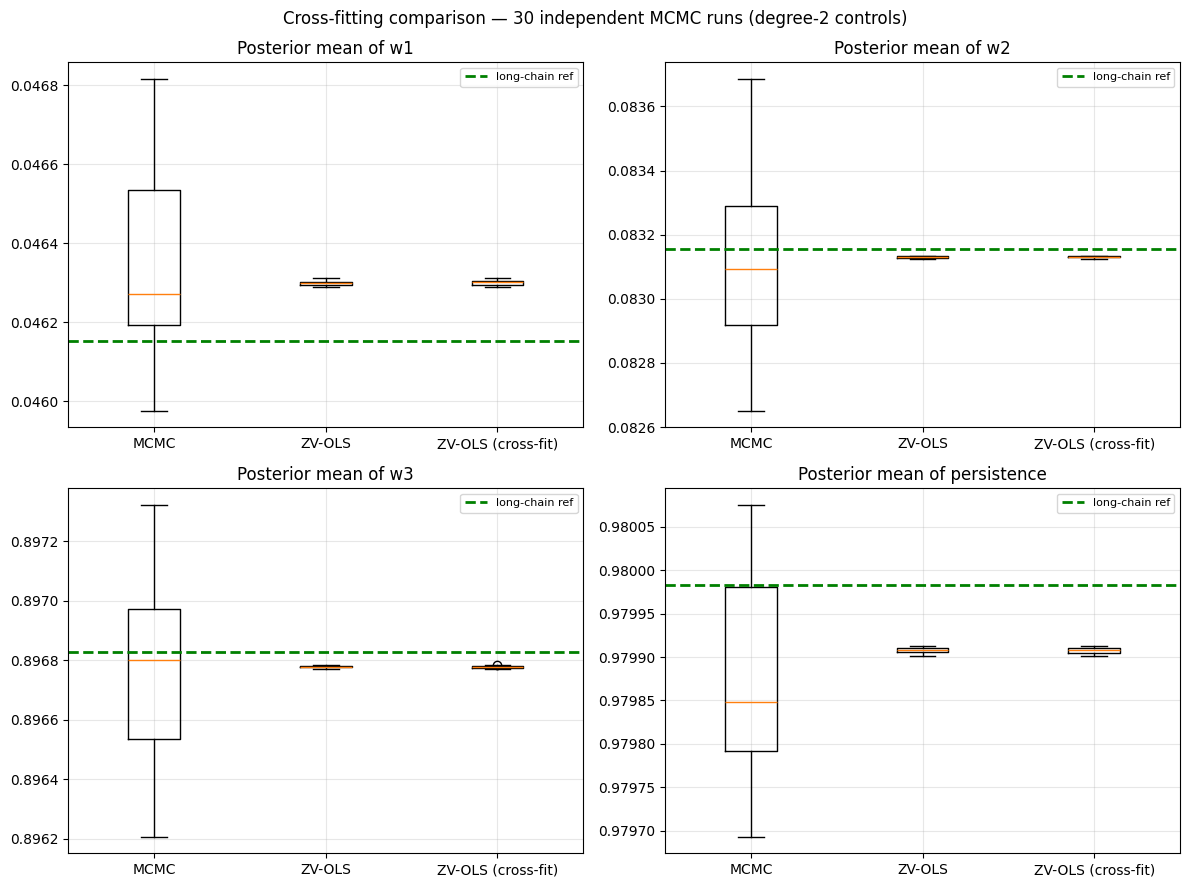

,ref_posterior_mean,MCMC_bias,OLS_bias,OLS_CF_bias,MCMC_var,OLS_var,OLS_CF_var,VR_OLS,VR_OLS_CF
w1,0.046152,0.000186,0.000147,0.000147,4.983277e-08,3.090604e-11,3.557980e-11,1612.395671,1400.591546
w2,0.083155,-0.000043,-0.000024,-0.000024,6.295849e-08,6.057477e-12,6.508249e-12,10393.516936,9673.644233
w3,0.896828,-0.000064,-0.000050,-0.000051,7.409491e-08,1.180978e-11,1.345598e-11,6274.028793,5506.466283
persistence,0.979983,-0.000107,-0.000075,-0.000075,1.284865e-08,9.246843e-12,1.088003e-11,1389.517028,1180.938766


In [61]:
# ============================================================
# QUESTION 3 — STEP 5b: Cross-fitting comparison
# Compare ZV-OLS (full-chain) and ZV-OLS-CF (cross-fit) across repeated
# runs on the same fixed dataset.
# ============================================================

def zv_estimator_ols_cf(f_vals, W):
    """Cross-fit ZV-OLS estimator. Splits the sample in two halves, fits
    OLS on each half, applies the slope coefficients to the *other* half,
    and averages the two correction-applied means.
    """
    N = len(f_vals)
    half = N // 2
    f_A, f_B = f_vals[:half], f_vals[half:2*half]
    W_A, W_B = W[:half], W[half:2*half]

    def _fit_apply(f_train, W_train, f_apply, W_apply):
        N_t = len(f_train)
        Wc = np.concatenate([np.ones((N_t, 1)), W_train], axis=1)
        beta, *_ = np.linalg.lstsq(Wc, f_train, rcond=None)
        return float(np.mean(f_apply) - beta[1:] @ W_apply.mean(axis=0))

    mu_A = _fit_apply(f_A, W_A, f_B, W_B)   # fit on A, apply on B
    mu_B = _fit_apply(f_B, W_B, f_A, W_A)   # fit on B, apply on A
    return 0.5 * (mu_A + mu_B)


# Repeated runs (reuse the chains we already computed in cell 55? No — recompute
# to keep the cell self-contained and aligned with the cross-fit logic).
n_rep_cf = 30
target_names_cf = ["w1", "w2", "w3", "persistence"]

mc_runs_cf      = {n: [] for n in target_names_cf}
ols_runs_cf     = {n: [] for n in target_names_cf}
ols_cf_runs_cf  = {n: [] for n in target_names_cf}  # cross-fit version

for rep in range(n_rep_cf):
    rng_mcmc_rep = np.random.default_rng(8000 + rep)
    chain_rep, acc_rep, _ = adaptive_rwm(
        r=r_fixed,
        prior=prior,
        n_iter=20000,
        omega0=omega0_q3,
        rng=rng_mcmc_rep,
        pilot_iter=2000,
        burn_in=1000,
    )
    Z_rep = all_z(chain_rep, r_fixed, prior)
    W2_rep = build_controls(chain_rep, Z_rep, degree=2)

    targets_vals = {
        "w1": chain_rep[:, 0],
        "w2": chain_rep[:, 1],
        "w3": chain_rep[:, 2],
        "persistence": chain_rep[:, 1] + chain_rep[:, 2],
    }
    for name in target_names_cf:
        f_rep = targets_vals[name]
        mc_runs_cf[name].append(float(np.mean(f_rep)))
        mu_ols, _ = zv_estimator_ols(f_rep, W2_rep)
        ols_runs_cf[name].append(mu_ols)
        mu_cf = zv_estimator_ols_cf(f_rep, W2_rep)
        ols_cf_runs_cf[name].append(mu_cf)

mc_runs_cf      = {k: np.asarray(v) for k, v in mc_runs_cf.items()}
ols_runs_cf     = {k: np.asarray(v) for k, v in ols_runs_cf.items()}
ols_cf_runs_cf  = {k: np.asarray(v) for k, v in ols_cf_runs_cf.items()}

# Boxplot: MCMC | ZV-OLS | ZV-OLS-CF
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, name in zip(axes.ravel(), target_names_cf):
    ax.boxplot(
        [mc_runs_cf[name], ols_runs_cf[name], ols_cf_runs_cf[name]],
        labels=["MCMC", "ZV-OLS", "ZV-OLS (cross-fit)"],
    )
    ax.axhline(ref_targets[name], color="green", linestyle="--",
               linewidth=2, label="long-chain ref")
    ax.set_title(f"Posterior mean of {name}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)
fig.suptitle(
    f"Cross-fitting comparison — {n_rep_cf} independent MCMC runs (degree-2 controls)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

# Bias and variance table
cf_table = pd.DataFrame(
    {
        "ref_posterior_mean": [ref_targets[n] for n in target_names_cf],
        "MCMC_bias":     [mc_runs_cf[n].mean()      - ref_targets[n] for n in target_names_cf],
        "OLS_bias":      [ols_runs_cf[n].mean()     - ref_targets[n] for n in target_names_cf],
        "OLS_CF_bias":   [ols_cf_runs_cf[n].mean()  - ref_targets[n] for n in target_names_cf],
        "MCMC_var":      [mc_runs_cf[n].var(ddof=1)     for n in target_names_cf],
        "OLS_var":       [ols_runs_cf[n].var(ddof=1)    for n in target_names_cf],
        "OLS_CF_var":    [ols_cf_runs_cf[n].var(ddof=1) for n in target_names_cf],
        "VR_OLS":        [
            mc_runs_cf[n].var(ddof=1) / ols_runs_cf[n].var(ddof=1)
            if ols_runs_cf[n].var(ddof=1) > 0 else np.nan
            for n in target_names_cf
        ],
        "VR_OLS_CF":     [
            mc_runs_cf[n].var(ddof=1) / ols_cf_runs_cf[n].var(ddof=1)
            if ols_cf_runs_cf[n].var(ddof=1) > 0 else np.nan
            for n in target_names_cf
        ],
    },
    index=target_names_cf,
)
display(cf_table)


## Application of ZV controls to EUR/USD log-returns

Using r_fx: T=1563, std=4.4480e-03
Ref chain (1.1s): acc=0.304, length=200000

param             posterior mean    posterior std       ESS           MC SE
w1                  3.774948e-07       1.5964e-07      3283        2.79e-09
w2                  5.181829e-02       1.1508e-02      6032        1.48e-04
w3                  9.296484e-01       1.6963e-02      3677        2.80e-04
Repeated runs done (25.2s)
Average acceptance rate over 15 runs: 0.345


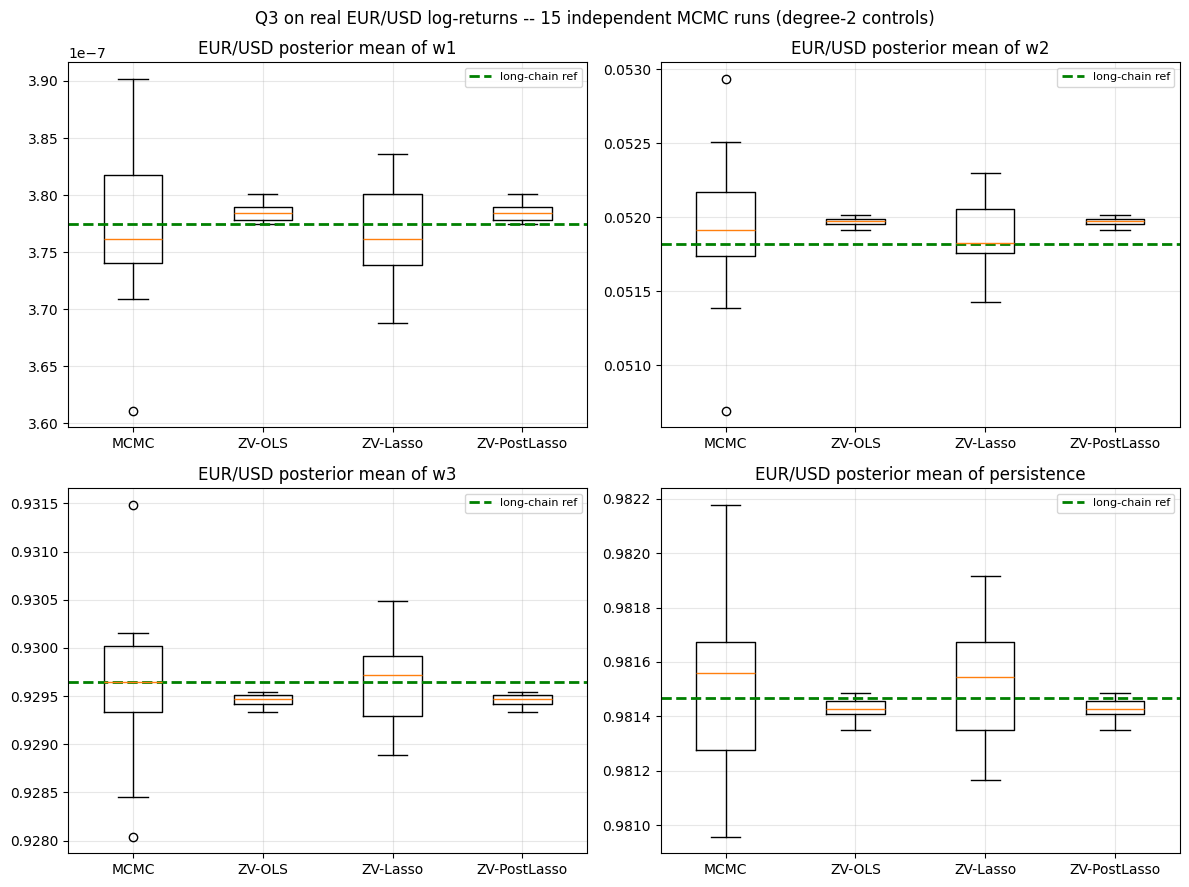

,ref_posterior_mean,MCMC_mean,OLS_mean,MCMC_var,OLS_var,Lasso_var,Post_var,VR_OLS,VR_Lasso,VR_PostLasso
w1,3.774948e-07,3.773968e-07,3.784934e-07,5.766025e-17,6.233239e-19,1.907385e-17,6.233239e-19,92.504468,3.023000,92.504468
w2,5.181829e-02,5.193479e-02,5.196914e-02,2.720279e-07,7.772649e-10,6.629089e-08,7.772649e-10,349.981001,4.103549,349.981001
w3,9.296484e-01,9.295758e-01,9.294579e-01,7.014297e-07,4.002560e-09,2.235528e-07,4.002560e-09,175.245249,3.137647,175.245249
persistence,9.814667e-01,9.815106e-01,9.814270e-01,1.331804e-07,1.578603e-09,4.760696e-08,1.578603e-09,84.366009,2.797499,84.366009


,MCMC_bias_vs_ref,OLS_bias_vs_ref,Lasso_bias_vs_ref,Post_bias_vs_ref
w1,-9.805150e-11,9.985388e-10,-6.892818e-10,9.985388e-10
w2,1.164998e-04,1.508517e-04,6.895527e-05,1.508517e-04
w3,-7.261903e-05,-1.905162e-04,-1.867813e-05,-1.905162e-04
persistence,4.388079e-05,-3.966448e-05,5.030197e-05,-3.966448e-05


In [62]:
# ============================================================
# Q3 on real EUR/USD log-returns
#
# IMPORTANT: we use `adaptive_rwm_fx` here, not the generic `adaptive_rwm`.
# On EUR/USD log-returns, omega_1 has posterior mean ~1e-6 (vs ~0.05 on
# the simulated dataset), so the default pilot proposal
# diag([1e-4, 1e-3, 1e-3]) is ~100x too large in the omega_1 direction
# and gives an acceptance rate close to zero. The fx-specific calibration
# scales the pilot proposal relative to the magnitude of each parameter.
# ============================================================
import warnings
warnings.filterwarnings("ignore")

print(f"Using r_fx: T={len(r_fx)}, std={r_fx.std():.4e}")

omega0_fx = np.array([1e-6, 0.05, 0.93])  # typical FX-GARCH initial values

# Long reference chain (FX-tuned proposal)
t0 = time.time()
ref_chain_fx, ref_acc_fx, _ = adaptive_rwm_fx(
    r=r_fx,
    prior=prior,
    n_iter=200_000,
    omega0=omega0_fx,
    rng=np.random.default_rng(1234),
    pilot_iter=5000,
    burn_in=10_000,
)
print(f"Ref chain ({time.time()-t0:.1f}s): acc={ref_acc_fx:.3f}, length={len(ref_chain_fx)}")

ref_targets_fx = {
    "w1":          float(ref_chain_fx[:, 0].mean()),
    "w2":          float(ref_chain_fx[:, 1].mean()),
    "w3":          float(ref_chain_fx[:, 2].mean()),
    "persistence": float((ref_chain_fx[:, 1] + ref_chain_fx[:, 2]).mean()),
}
ref_stds_fx = {
    "w1":          float(ref_chain_fx[:, 0].std()),
    "w2":          float(ref_chain_fx[:, 1].std()),
    "w3":          float(ref_chain_fx[:, 2].std()),
    "persistence": float((ref_chain_fx[:, 1] + ref_chain_fx[:, 2]).std()),
}
ref_ess_fx = np.array([effective_sample_size(ref_chain_fx[:, k]) for k in range(3)])

print()
print(f"{'param':12s}  {'posterior mean':>18s}  {'posterior std':>15s}  {'ESS':>8s}  {'MC SE':>14s}")
for k, name in enumerate(['w1', 'w2', 'w3']):
    se_k = ref_stds_fx[name] / np.sqrt(ref_ess_fx[k])
    print(f"{name:12s}  {ref_targets_fx[name]:>18.6e}  {ref_stds_fx[name]:>15.4e}  {int(ref_ess_fx[k]):>8d}  {se_k:>14.2e}")

# Repeated runs (FX-tuned proposal)
n_rep_fx = 15
target_names_fx = ["w1", "w2", "w3", "persistence"]
mc_runs_fx = {n: [] for n in target_names_fx}
ols_runs_fx = {n: [] for n in target_names_fx}
lasso_runs_fx = {n: [] for n in target_names_fx}
post_runs_fx = {n: [] for n in target_names_fx}
acc_rates_fx = []

t0 = time.time()
for rep in range(n_rep_fx):
    rng_mcmc = np.random.default_rng(11000 + rep)
    chain_rep, acc_rep, _ = adaptive_rwm_fx(
        r=r_fx,
        prior=prior,
        n_iter=20000,
        omega0=omega0_fx,
        rng=rng_mcmc,
        pilot_iter=3000,
        burn_in=1000,
    )
    acc_rates_fx.append(acc_rep)
    Z_rep = all_z(chain_rep, r_fx, prior)
    W2_rep = build_controls(chain_rep, Z_rep, degree=2)

    targets_vals = {
        "w1": chain_rep[:, 0],
        "w2": chain_rep[:, 1],
        "w3": chain_rep[:, 2],
        "persistence": chain_rep[:, 1] + chain_rep[:, 2],
    }
    for name in target_names_fx:
        f_rep = targets_vals[name]
        mc_runs_fx[name].append(float(np.mean(f_rep)))
        mu_ols, _ = zv_estimator_ols(f_rep, W2_rep)
        ols_runs_fx[name].append(mu_ols)
        mu_lasso = zv_estimator_lasso(f_rep, W2_rep, cv=3)
        lasso_runs_fx[name].append(mu_lasso)
        mu_post = zv_estimator_post_lasso(f_rep, W2_rep, cv=3)
        post_runs_fx[name].append(mu_post)
print(f"Repeated runs done ({time.time()-t0:.1f}s)")
print(f"Average acceptance rate over {n_rep_fx} runs: {np.mean(acc_rates_fx):.3f}")

mc_runs_fx = {k: np.asarray(v) for k, v in mc_runs_fx.items()}
ols_runs_fx = {k: np.asarray(v) for k, v in ols_runs_fx.items()}
lasso_runs_fx = {k: np.asarray(v) for k, v in lasso_runs_fx.items()}
post_runs_fx = {k: np.asarray(v) for k, v in post_runs_fx.items()}

# Boxplot
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, name in zip(axes.ravel(), target_names_fx):
    ax.boxplot(
        [mc_runs_fx[name], ols_runs_fx[name], lasso_runs_fx[name], post_runs_fx[name]],
        labels=["MCMC", "ZV-OLS", "ZV-Lasso", "ZV-PostLasso"],
    )
    ax.axhline(ref_targets_fx[name], color="green", linestyle="--",
               linewidth=2, label="long-chain ref")
    ax.set_title(f"EUR/USD posterior mean of {name}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)
fig.suptitle(
    f"Q3 on real EUR/USD log-returns -- {n_rep_fx} independent MCMC runs (degree-2 controls)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

# Variance-reduction table
ratio_table_fx = pd.DataFrame(
    {
        "ref_posterior_mean": [ref_targets_fx[n] for n in target_names_fx],
        "MCMC_mean":   [mc_runs_fx[n].mean() for n in target_names_fx],
        "OLS_mean":    [ols_runs_fx[n].mean() for n in target_names_fx],
        "MCMC_var":    [mc_runs_fx[n].var(ddof=1) for n in target_names_fx],
        "OLS_var":     [ols_runs_fx[n].var(ddof=1) for n in target_names_fx],
        "Lasso_var":   [lasso_runs_fx[n].var(ddof=1) for n in target_names_fx],
        "Post_var":    [post_runs_fx[n].var(ddof=1) for n in target_names_fx],
        "VR_OLS":      [
            mc_runs_fx[n].var(ddof=1) / ols_runs_fx[n].var(ddof=1)
            if ols_runs_fx[n].var(ddof=1) > 0 else np.nan
            for n in target_names_fx
        ],
        "VR_Lasso":    [
            mc_runs_fx[n].var(ddof=1) / lasso_runs_fx[n].var(ddof=1)
            if lasso_runs_fx[n].var(ddof=1) > 0 else np.nan
            for n in target_names_fx
        ],
        "VR_PostLasso":[
            mc_runs_fx[n].var(ddof=1) / post_runs_fx[n].var(ddof=1)
            if post_runs_fx[n].var(ddof=1) > 0 else np.nan
            for n in target_names_fx
        ],
    },
    index=target_names_fx,
)
display(ratio_table_fx)

# Bias relative to reference
bias_table_fx = pd.DataFrame(
    {
        "MCMC_bias_vs_ref":  [mc_runs_fx[n].mean()    - ref_targets_fx[n] for n in target_names_fx],
        "OLS_bias_vs_ref":   [ols_runs_fx[n].mean()   - ref_targets_fx[n] for n in target_names_fx],
        "Lasso_bias_vs_ref": [lasso_runs_fx[n].mean() - ref_targets_fx[n] for n in target_names_fx],
        "Post_bias_vs_ref":  [post_runs_fx[n].mean()  - ref_targets_fx[n] for n in target_names_fx],
    },
    index=target_names_fx,
)
display(bias_table_fx)


## 4. Question 4 (bonus): Validity of regression on an MCMC chain

### 4.1 Problem

OLS is optimal for iid samples. The choice $a^\star = -\Sigma_{zz}^{-1}\mathrm{Cov}(z,f)$ remains consistent under chain ergodicity, but serial dependence inflates the variance of $\hat a$. We test two remedies:

- **Thinning**: keep one sample every $k$ to estimate $\hat a$, then evaluate the ZV estimator on the full chain.
- **Block averaging**: replace the chain by averages over consecutive blocks of size $B$, then regress.

In [63]:
def zv_ols_with_thinning(chain, Z, f_vals, thin=1):
    """Zero-Variance OLS with *thinning*: subsample the chain every `thin`
    iterations to estimate hat beta on approximately de-correlated states,
    then evaluate the ZV correction mean(f) - beta @ mean(W) on the FULL
    chain (to keep the full precision of the averages). Uses a degree-2
    control-variate design."""
    W_full = build_controls(chain, Z, degree=2)
    W_thin = W_full[::thin]
    f_thin = f_vals[::thin]
    N_thin = len(f_thin)
    Wc_thin = np.concatenate([np.ones((N_thin, 1)), W_thin], axis=1)
    beta, *_ = np.linalg.lstsq(Wc_thin, f_thin, rcond=None)
    mu_zv = float(np.mean(f_vals) - beta[1:] @ W_full.mean(axis=0))
    return mu_zv


def zv_ols_with_block_averaging(chain, Z, f_vals, block_size=50):
    """Zero-Variance OLS on *block averages*: regroup the chain into
    consecutive blocks of size `block_size` and regress the block-averages
    of f on the block-averages of the control variates. The block-averaging
    reduces autocorrelation before fitting (a `batch means` trick), which
    often stabilises the ZV correction. Uses a degree-2 design."""
    W_full = build_controls(chain, Z, degree=2)
    N = len(f_vals)
    n_blocks = N // block_size
    W_full = W_full[:n_blocks * block_size]
    f_vals_tr = f_vals[:n_blocks * block_size]
    W_blocks = W_full.reshape(n_blocks, block_size, -1).mean(axis=1)
    f_blocks = f_vals_tr.reshape(n_blocks, block_size).mean(axis=1)
    Wc = np.concatenate([np.ones((n_blocks, 1)), W_blocks], axis=1)
    beta, *_ = np.linalg.lstsq(Wc, f_blocks, rcond=None)
    mu_zv = float(np.mean(f_vals_tr) - beta[1:] @ W_full.mean(axis=0))
    return mu_zv

### 4.2 Empirical autocorrelation

We measure the autocorrelation of the three components on a 20,000-iteration chain.

In [64]:
# Autocorrelation and ESS
rng = np.random.default_rng(777)
test_chain, _ = rwm(r, prior, 20_000, omega_start, Sigma_prop, rng, burn_in=2000)
ess = [effective_sample_size(test_chain[:, k]) for k in range(3)]
int_autocorr = [len(test_chain) / e for e in ess]
print(f"ESS over 20k iterations          : {[int(e) for e in ess]}")
print(f"Integrated autocorrelation time  : {[f'{t:.1f}' for t in int_autocorr]}")

ESS over 20k iterations          : [1011, 1029, 897]
Integrated autocorrelation time  : ['19.8', '19.4', '22.3']


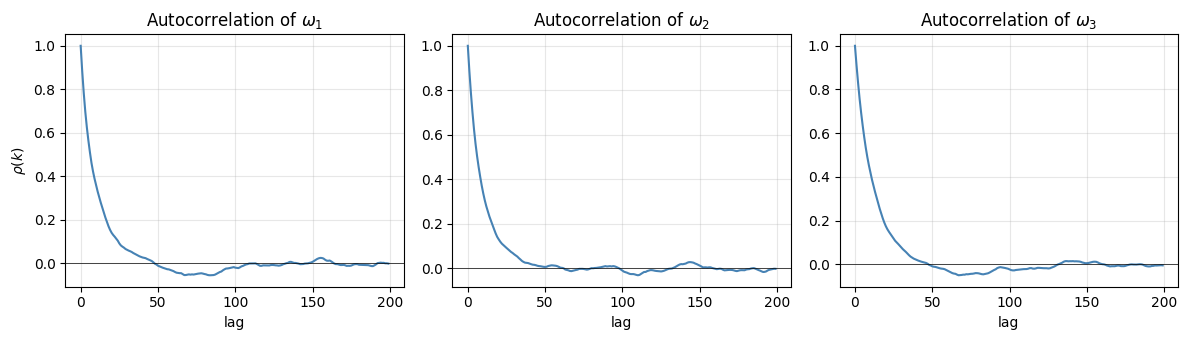

In [65]:
# Empirical autocorrelation function
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
max_lag = 200
for k in range(3):
    x = test_chain[:, k] - test_chain[:, k].mean()
    var = np.var(x)
    ac = np.array([np.mean(x[:len(x) - l] * x[l:]) / var for l in range(max_lag)])
    axes[k].plot(ac, color="steelblue")
    axes[k].axhline(0, color="black", lw=0.5)
    axes[k].set_title(f"Autocorrelation of {param_names[k]}")
    axes[k].set_xlabel("lag")
    axes[k].grid(alpha=0.3)
axes[0].set_ylabel(r"$\rho(k)$")
plt.tight_layout()
plt.show()

### 4.3 Comparing strategies

In [66]:
# Bonus experiment: strategy comparison
n_reps_b = 50
n_iter_b = 10_000
methods_b = ["raw", "thin_5", "thin_10", "thin_20",
             "block_10", "block_50", "block_100"]
results_b = {m: np.zeros((n_reps_b, 3)) for m in methods_b}

t0 = time.time()
for rep in range(n_reps_b):
    rng = np.random.default_rng(8000 + rep)
    chain, _ = rwm(r, prior, n_iter_b, omega_start, Sigma_prop, rng, burn_in=1000)
    Z = all_z(chain, r, prior)
    for k in range(3):
        f = chain[:, k]
        W = build_controls(chain, Z, degree=2)
        mu, _ = zv_estimator_ols(f, W)
        results_b["raw"][rep, k] = mu
        for thin_k in [5, 10, 20]:
            results_b[f"thin_{thin_k}"][rep, k] = zv_ols_with_thinning(chain, Z, f, thin=thin_k)
        for B in [10, 50, 100]:
            results_b[f"block_{B}"][rep, k] = zv_ols_with_block_averaging(chain, Z, f, block_size=B)
    if (rep + 1) % 10 == 0:
        print(f"  rep {rep+1}/{n_reps_b}  t={time.time()-t0:.1f}s")

print(f"Total: {time.time()-t0:.1f}s")

  rep 10/50  t=4.1s
  rep 20/50  t=8.3s
  rep 30/50  t=12.5s
  rep 40/50  t=16.8s
  rep 50/50  t=21.0s
Total: 21.0s


In [67]:
# Ratios table.
# Reference is the "raw" strategy (regression on the full chain): we report
# Var(raw) / Var(method) so that values > 1 mean the method does better.
vplain = results_b["raw"].var(axis=0, ddof=1)
print("=" * 55)
print(f"{'Strategy':15s}  {'w1':>10s}  {'w2':>10s}  {'w3':>10s}")
print("=" * 55)
for m in methods_b:
    ratio = vplain / results_b[m].var(axis=0, ddof=1)
    print(f"{m:15s}  {ratio[0]:>10.1f}  {ratio[1]:>10.1f}  {ratio[2]:>10.1f}")
print("=" * 55)


Strategy                 w1          w2          w3
raw                     1.0         1.0         1.0
thin_5                  1.0         1.0         1.0
thin_10                 1.1         0.9         1.0
thin_20                 0.9         0.8         0.9
block_10                1.1         1.0         1.1
block_50                1.2         1.1         1.2
block_100               1.1         1.0         1.1


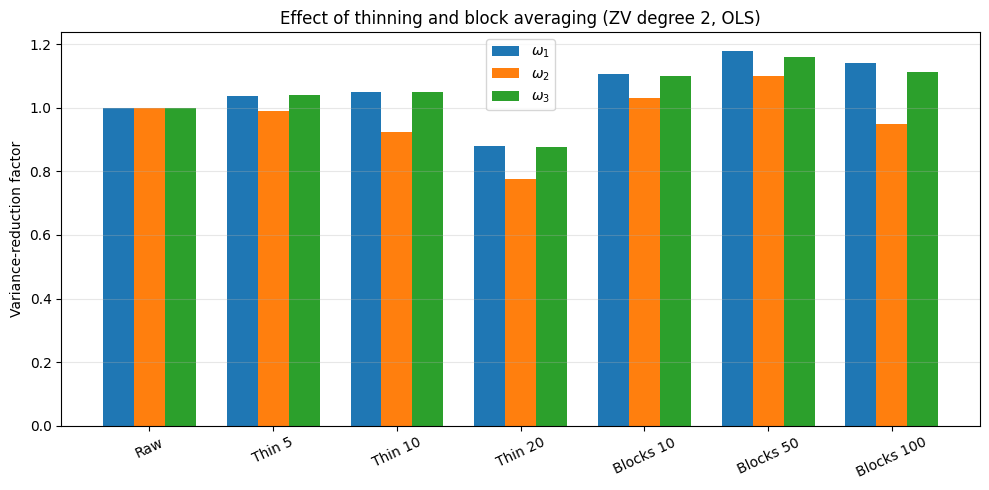

In [68]:
# Bar plot comparing the strategies
labels_bonus = ["Raw", "Thin 5", "Thin 10", "Thin 20", "Blocks 10", "Blocks 50", "Blocks 100"]
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
x = np.arange(len(methods_b))
width = 0.25
for k in range(3):
    ratios = np.array([vplain[k] / results_b[m].var(axis=0, ddof=1)[k] for m in methods_b])
    ax.bar(x + (k - 1) * width, ratios, width, label=param_names[k])
ax.set_xticks(x)
ax.set_xticklabels(labels_bonus, rotation=25)
ax.set_ylabel("Variance-reduction factor")
ax.set_title("Effect of thinning and block averaging (ZV degree 2, OLS)")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()